In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATASET
# ============================================================

csv_path = "../data/upi_daily_stats_cleaned.csv"
df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print()


# ============================================================
# 2. CONVERT DATE COLUMN
# ============================================================

df["Day"] = pd.to_datetime(df["Day"])


# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

print("First 5 records:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDescriptive statistics:")
print(df.describe())

print("\nDataset information:")
df.info()


# ============================================================
# 4. DATE COMPLETENESS CHECK
# ============================================================

print("\n" + "=" * 50)
print("DATE ANALYSIS")
print("=" * 50)

# Number of records
print("Total records:", len(df))

# Number of unique dates
print("Unique dates:", df["Day"].nunique())

# Date range
print("Start date:", df["Day"].min())
print("End date:", df["Day"].max())


# Create expected daily date range
expected_dates = pd.date_range(
    start=df["Day"].min(),
    end=df["Day"].max(),
    freq="D"
)

# Find missing dates
missing_dates = expected_dates.difference(
    df["Day"].dt.normalize()
)

print("\nExpected number of dates:", len(expected_dates))
print("Number of missing dates:", len(missing_dates))

if len(missing_dates) == 0:
    print("No dates are missing.")
else:
    print("Missing dates:")
    print(missing_dates)


# ============================================================
# 5. DUPLICATE DATE CHECK
# ============================================================

duplicate_dates = df[df["Day"].duplicated(keep=False)]

print("\nDuplicate date records:", len(duplicate_dates))

if len(duplicate_dates) == 0:
    print("No duplicate dates.")
else:
    print("Duplicate dates:")
    print(duplicate_dates)


# ============================================================
# 6. STATISTICAL ANALYSIS
# ============================================================

numerical_columns = [
    "Volume (In Mn.)",
    "Value (In Cr.)"
]

print("\n" + "=" * 50)
print("STATISTICAL ANALYSIS")
print("=" * 50)

# Descriptive statistics
print("\nDescriptive statistics:")
print(df[numerical_columns].describe())

# Variance
print("\nVariance:")
print(df[numerical_columns].var())

# Skewness
print("\nSkewness:")
print(df[numerical_columns].skew())


# ============================================================
# 7. OUTLIER ANALYSIS USING IQR
# ============================================================

print("\n" + "=" * 50)
print("OUTLIER ANALYSIS")
print("=" * 50)

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))

    if len(outliers) > 0:
        print("\nOutlier records:")
        print(outliers)
    else:
        print("No outliers detected.")

Dataset loaded successfully!

First 5 records:
         Day  Volume (In Mn.)  Value (In Cr.)
0 2021-05-01            86.24        18140.21
1 2021-05-02            79.37        13692.47
2 2021-05-03            87.72        20191.07
3 2021-05-04            89.31        20005.02
4 2021-05-05            87.70        19438.15

Dataset shape:
(1920, 3)

Descriptive statistics:
                       Day  Volume (In Mn.)  Value (In Cr.)
count                 1920      1920.000000     1920.000000
mean   2023-12-16 12:00:00       405.879370    57969.045719
min    2021-05-01 00:00:00        71.280000     9669.180000
25%    2022-08-23 18:00:00       214.502500    36065.967500
50%    2023-12-16 12:00:00       388.060000    56840.235000
75%    2025-04-09 06:00:00       591.217500    77481.847500
max    2026-08-02 00:00:00       848.790000   131735.460000
std                    NaN       209.298849    25831.794399

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
D

Date-based columns created successfully.


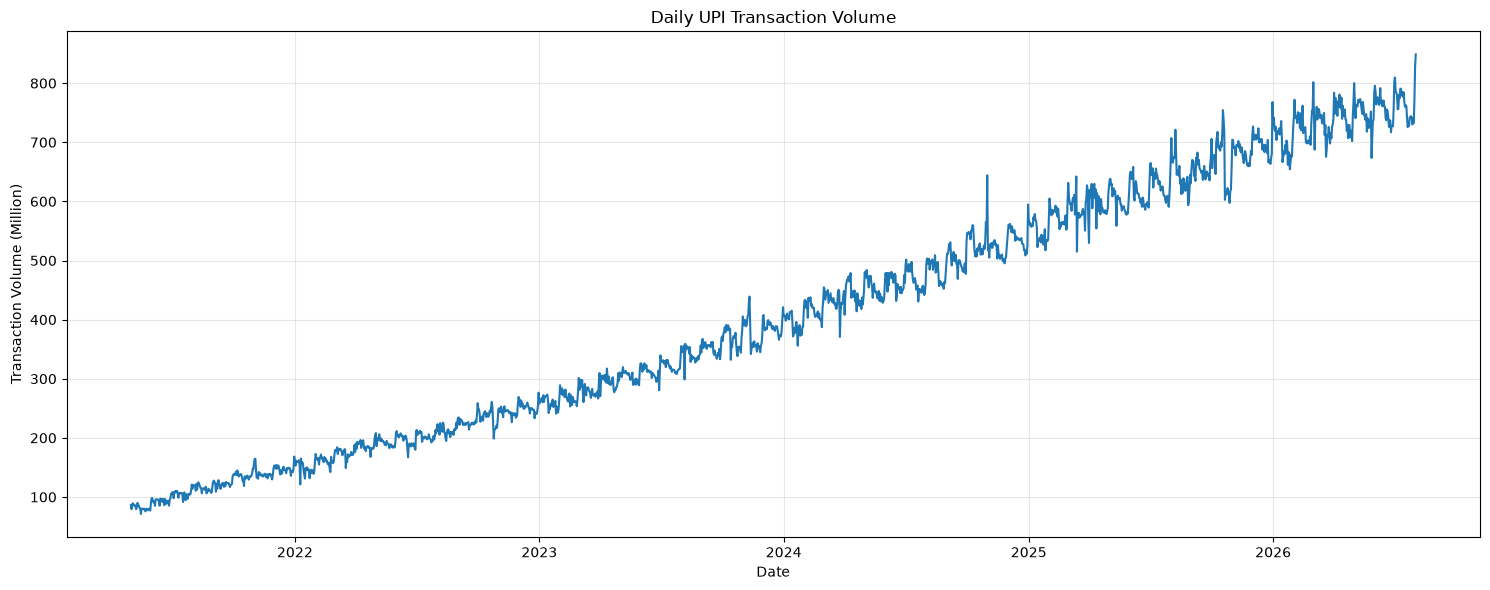

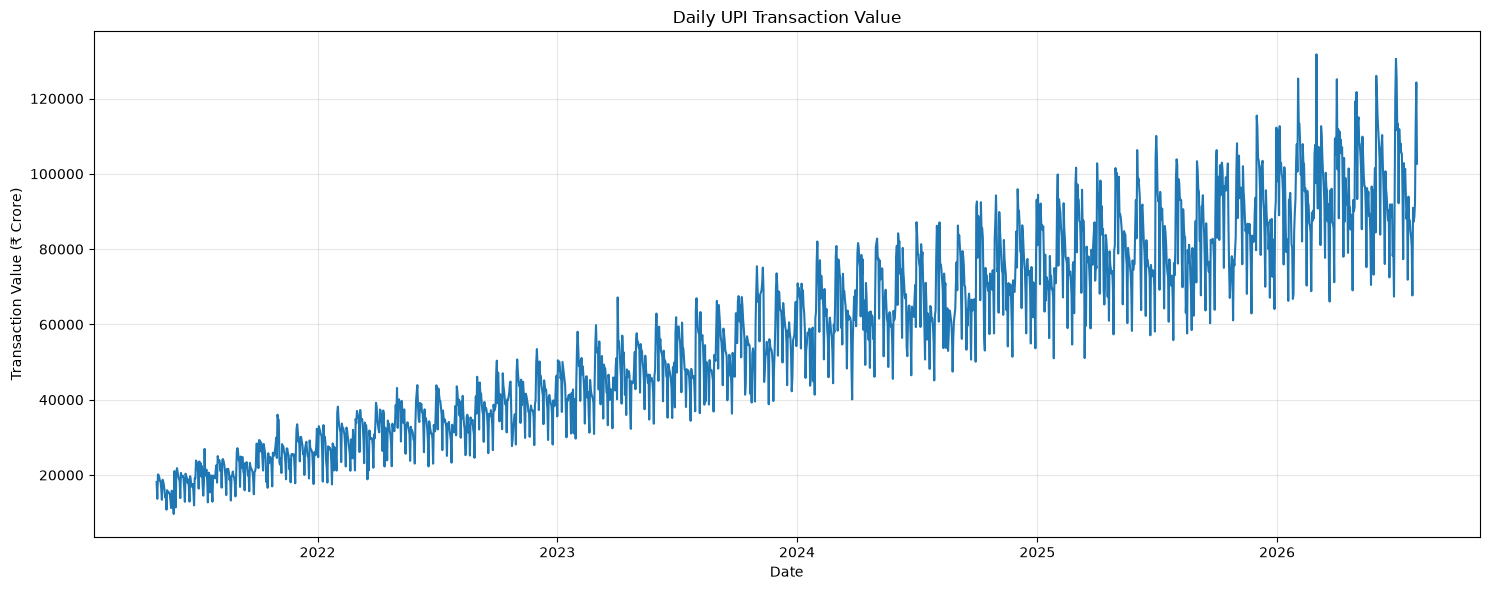


Monthly aggregated data:
         Day  Volume (In Mn.)  Value (In Cr.)
0 2021-05-31        81.921613    15818.082581
1 2021-06-30        93.583333    18245.772000
2 2021-07-31       104.768710    19544.619355
3 2021-08-31       114.694194    20616.675806
4 2021-09-30       121.811000    21821.609333


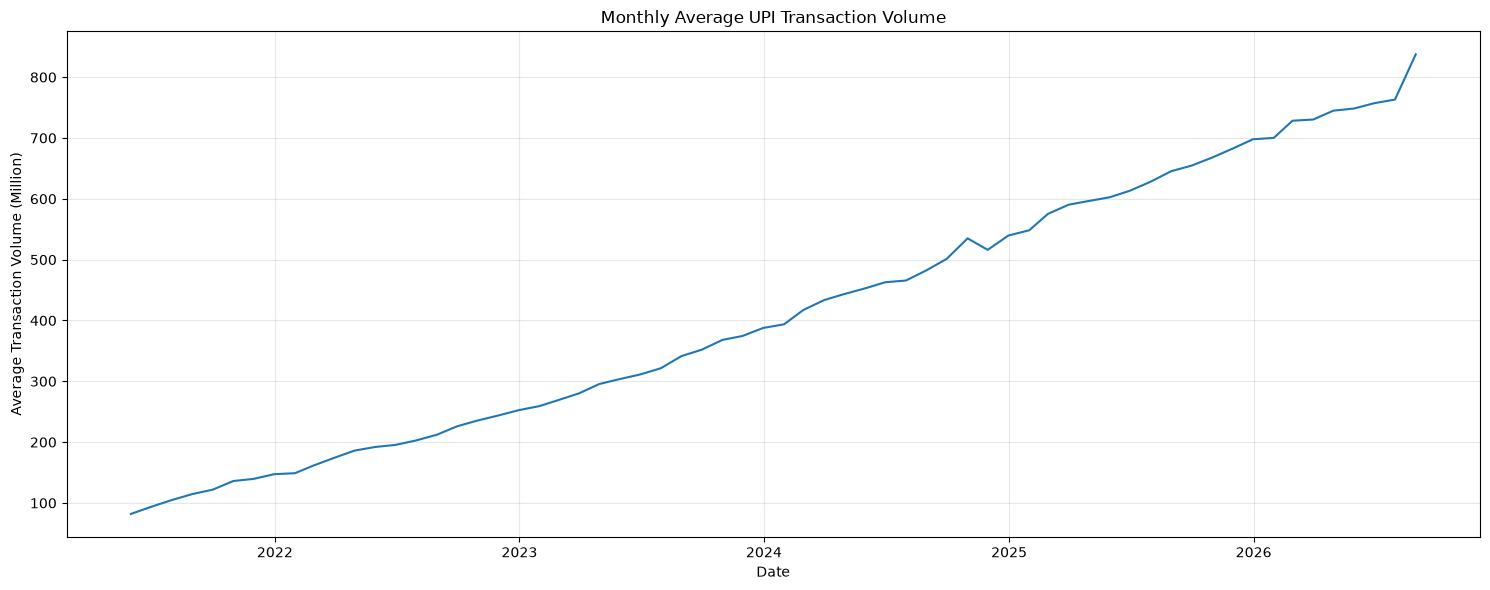

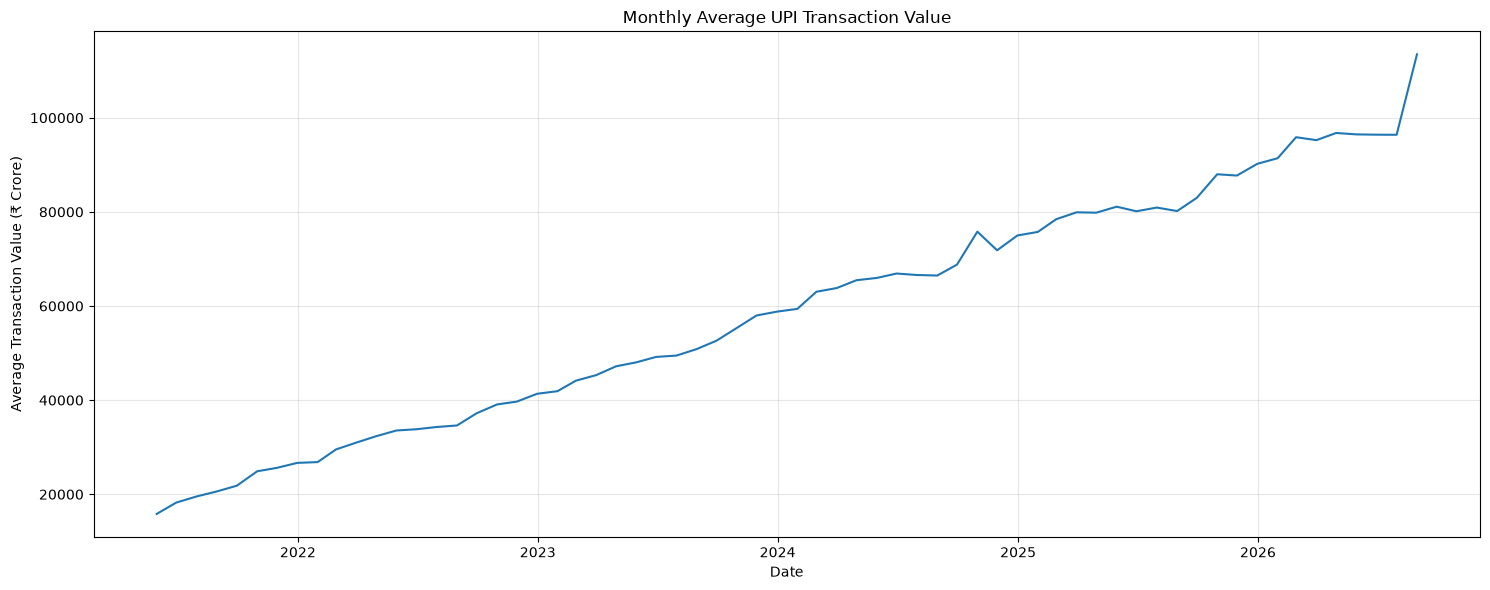


Yearly average statistics:
   Year  Volume (In Mn.)  Value (In Cr.)
0  2021       117.453755    21649.279429
1  2022       202.861644    34468.379397
2  2023       322.303260    50103.109370
3  2024       470.513825    67438.581475
4  2025       625.429918    82122.568630
5  2026       739.892757    95657.208178


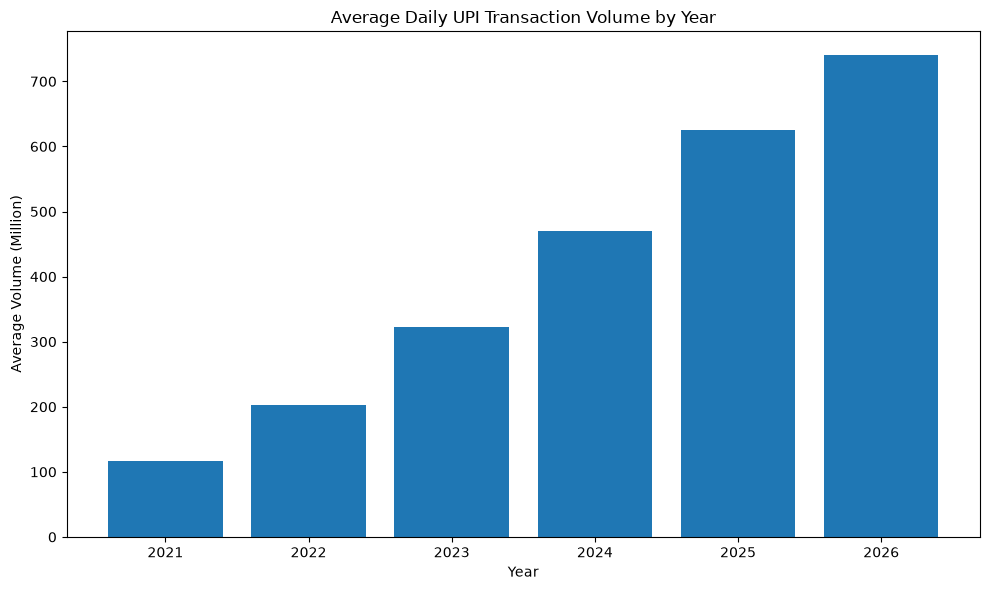

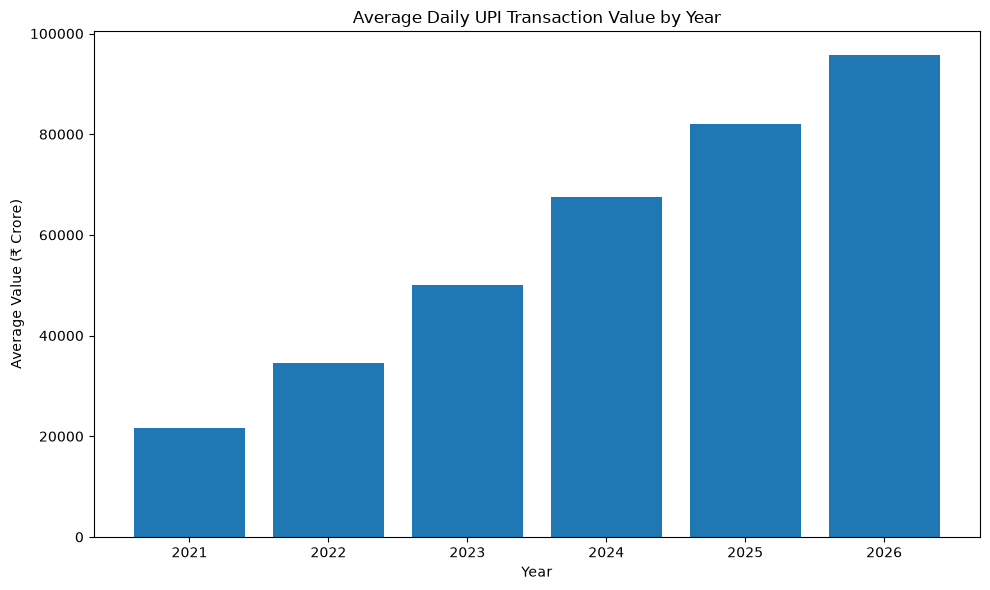

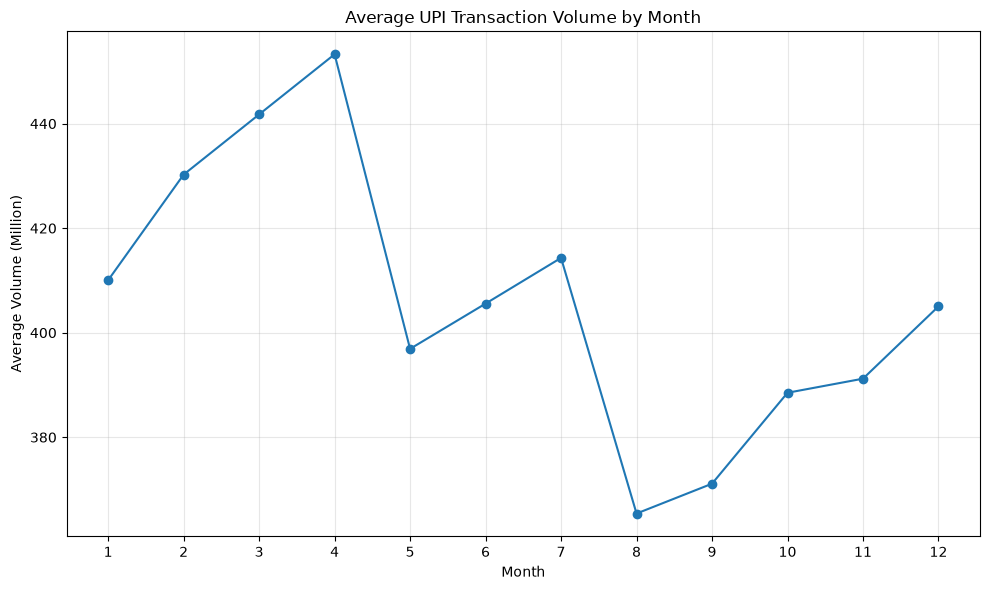

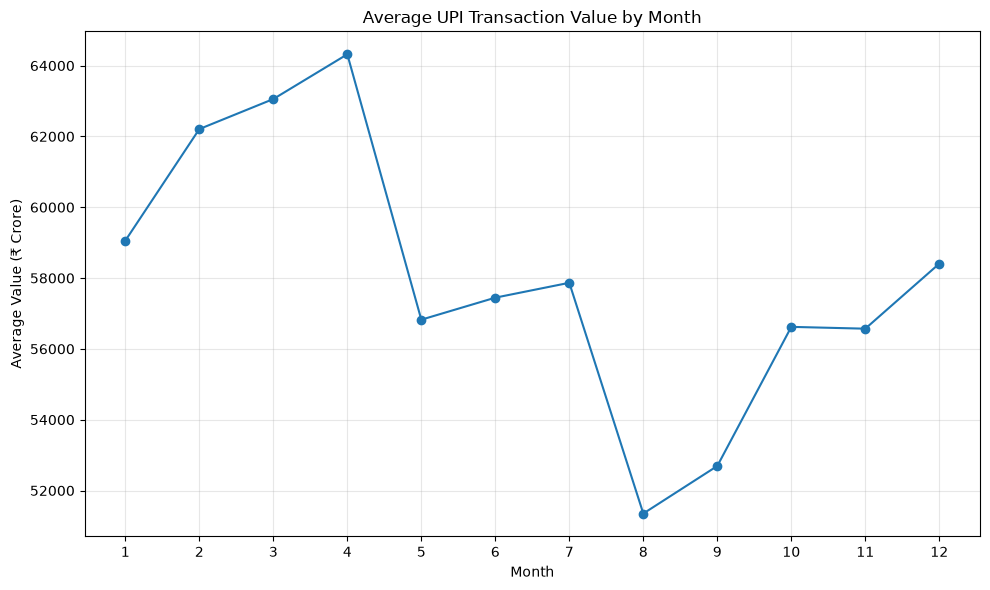

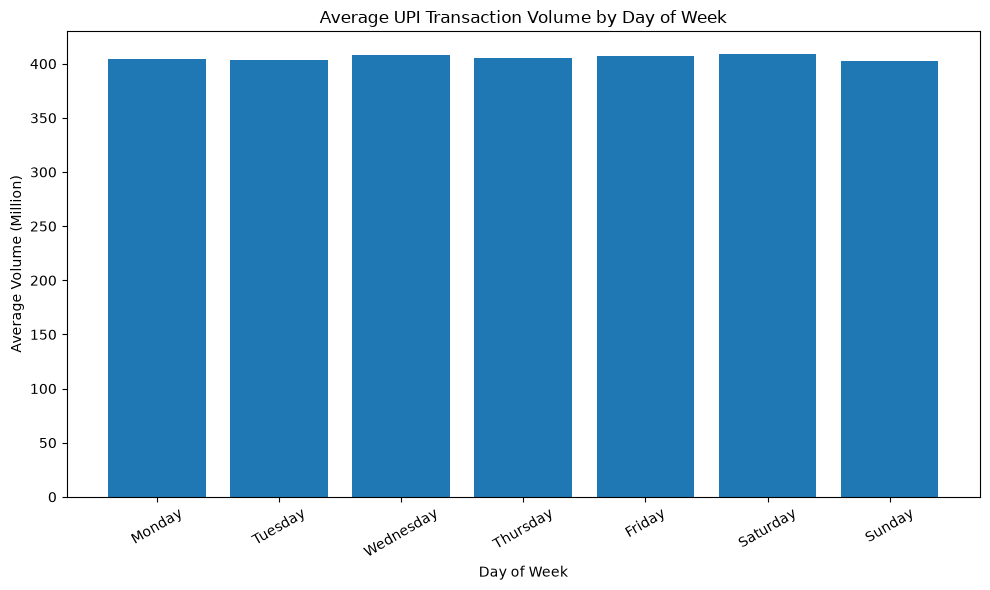

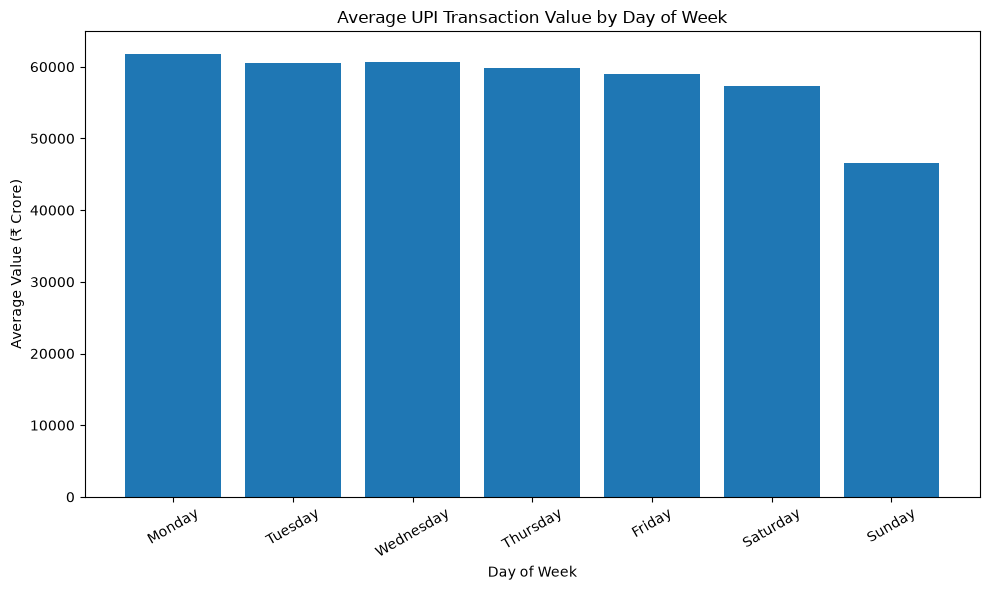

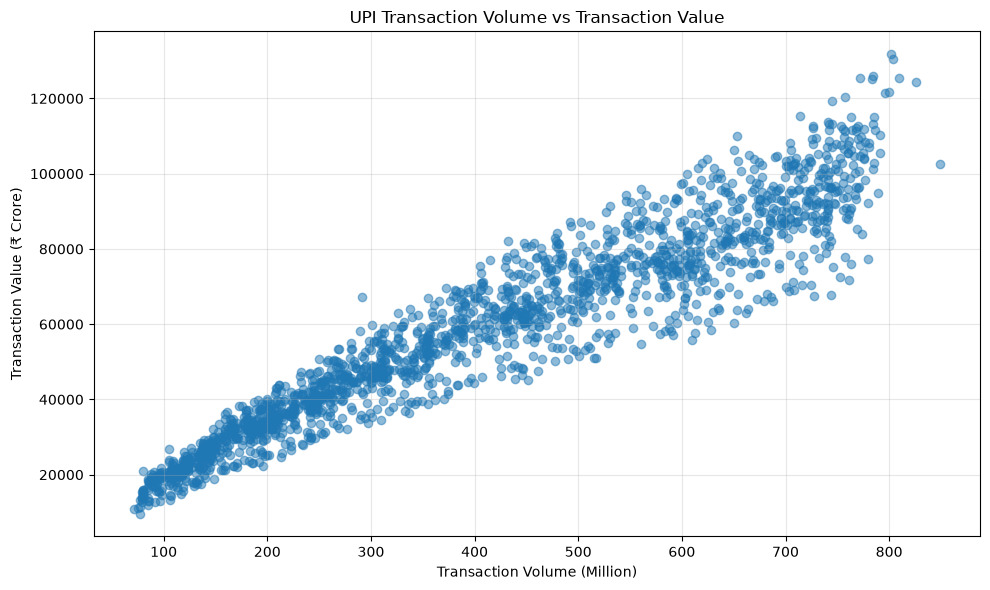


Correlation matrix:
                 Volume (In Mn.)  Value (In Cr.)
Volume (In Mn.)         1.000000        0.951459
Value (In Cr.)          0.951459        1.000000


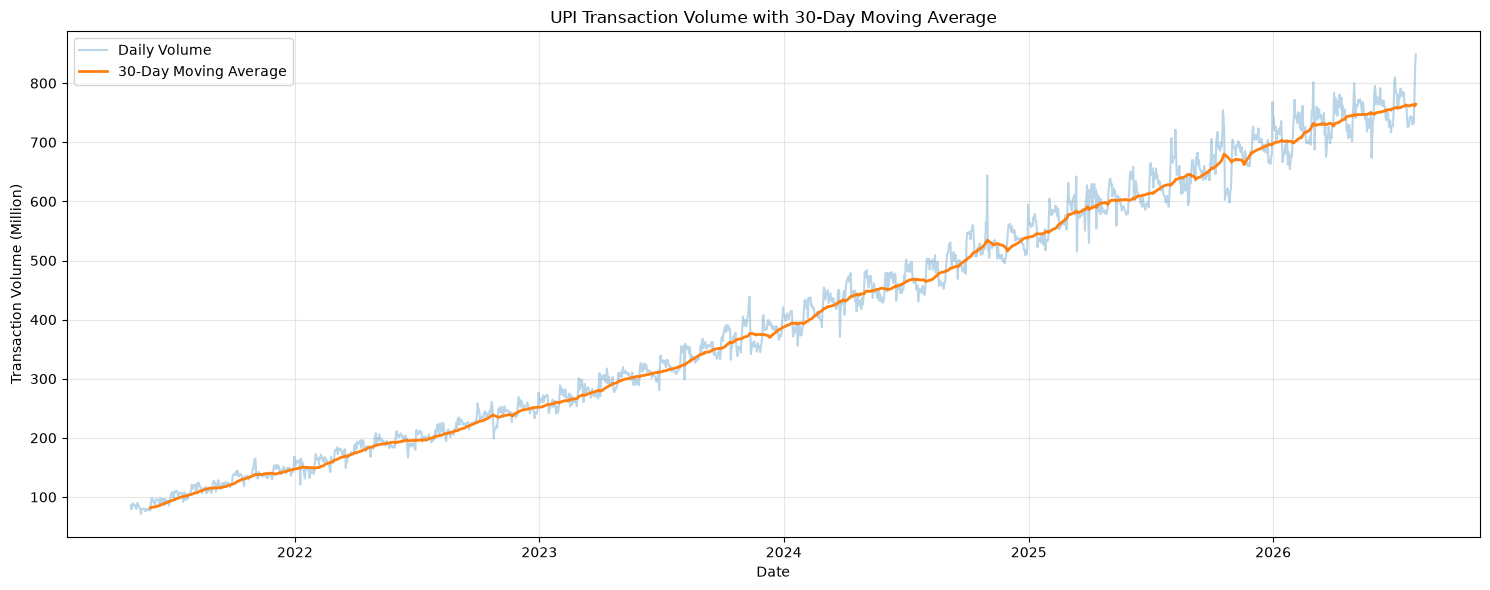

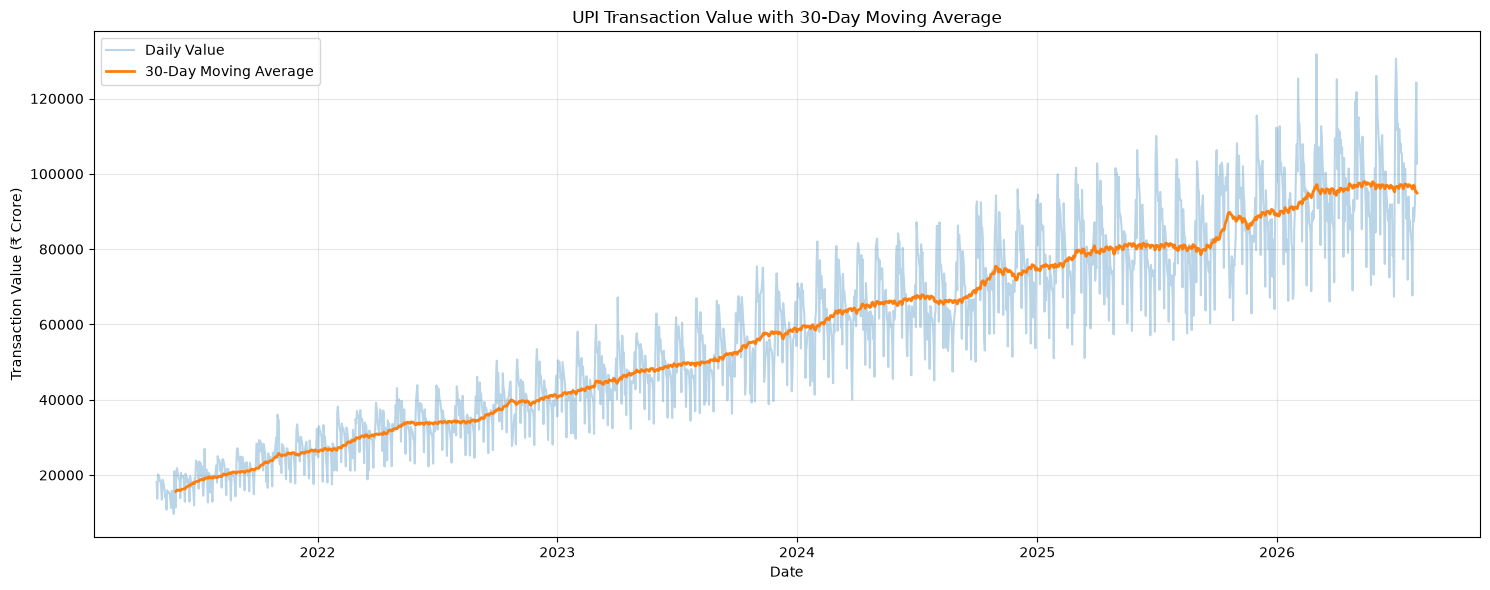


Year-over-year growth:
   Year  Volume (In Mn.)  Value (In Cr.)  Volume_Growth_%  Value_Growth_%
0  2021       117.453755    21649.279429              NaN             NaN
1  2022       202.861644    34468.379397        72.716184       59.212594
2  2023       322.303260    50103.109370        58.878364       45.359632
3  2024       470.513825    67438.581475        45.984817       34.599593
4  2025       625.429918    82122.568630        32.924876       21.773867
5  2026       739.892757    95657.208178        18.301465       16.481023


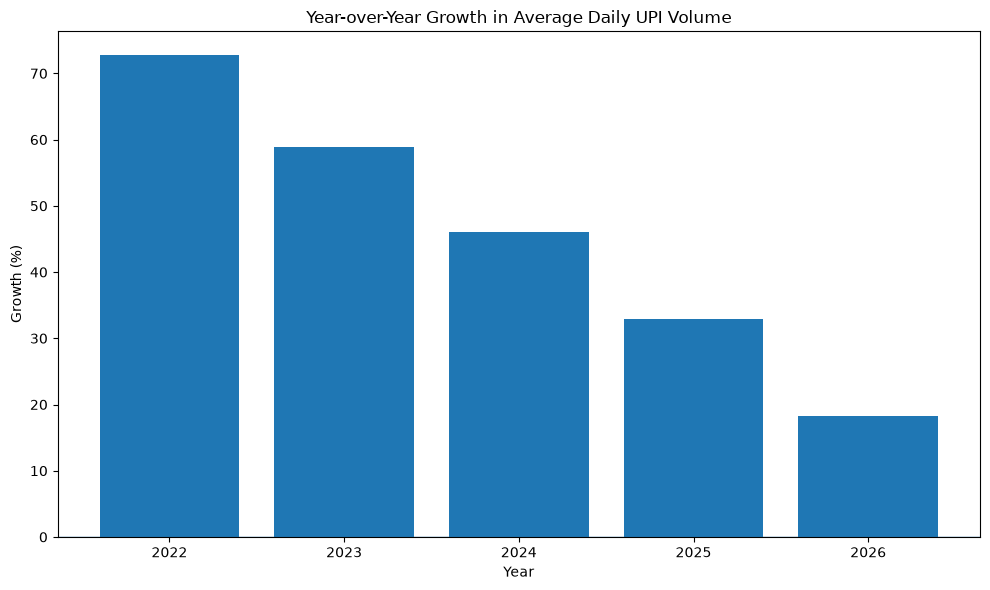

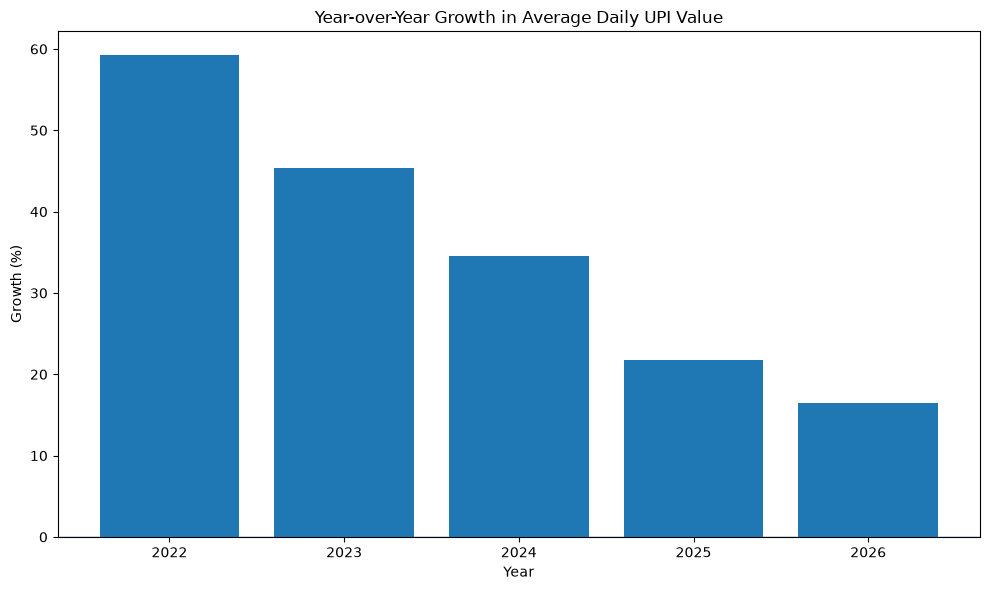


EDA STAGE 2 COMPLETE

Correlation between Volume and Value:
0.9514585952892021

Highest daily transaction volume:
Day                2026-08-02 00:00:00
Volume (In Mn.)                 848.79
Value (In Cr.)               102694.13
Year                              2026
Month                                8
Month_Name                      August
Day_of_Week                     Sunday
Day_of_Week_Num                      6
Volume_30D_MA               764.461667
Value_30D_MA                 94910.893
Name: 1919, dtype: object

Lowest daily transaction volume:
Day                2021-05-16 00:00:00
Volume (In Mn.)                  71.28
Value (In Cr.)                10804.95
Year                              2021
Month                                5
Month_Name                         May
Day_of_Week                     Sunday
Day_of_Week_Num                      6
Volume_30D_MA                      NaN
Value_30D_MA                       NaN
Name: 15, dtype: object

Highest daily transa

In [3]:
# ============================================================
# EDA STAGE 2
# VISUAL + TIME-SERIES ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. PREPARE DATE-BASED COLUMNS
# ============================================================

# Make sure data is chronologically ordered
df = df.sort_values("Day").reset_index(drop=True)

# Create useful time-based columns
df["Year"] = df["Day"].dt.year
df["Month"] = df["Day"].dt.month
df["Month_Name"] = df["Day"].dt.month_name()
df["Day_of_Week"] = df["Day"].dt.day_name()
df["Day_of_Week_Num"] = df["Day"].dt.dayofweek

print("Date-based columns created successfully.")


# ============================================================
# 2. DAILY TRANSACTION VOLUME TREND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    df["Day"],
    df["Volume (In Mn.)"]
)

plt.title("Daily UPI Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Transaction Volume (Million)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3. DAILY TRANSACTION VALUE TREND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    df["Day"],
    df["Value (In Cr.)"]
)

plt.title("Daily UPI Transaction Value")
plt.xlabel("Date")
plt.ylabel("Transaction Value (₹ Crore)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 4. MONTHLY AGGREGATION
# ============================================================

monthly_df = (
    df.set_index("Day")
      .resample("ME")
      .agg({
          "Volume (In Mn.)": "mean",
          "Value (In Cr.)": "mean"
      })
      .reset_index()
)

print("\nMonthly aggregated data:")
print(monthly_df.head())


# ============================================================
# 5. MONTHLY AVERAGE VOLUME TREND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_df["Day"],
    monthly_df["Volume (In Mn.)"]
)

plt.title("Monthly Average UPI Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Average Transaction Volume (Million)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 6. MONTHLY AVERAGE VALUE TREND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_df["Day"],
    monthly_df["Value (In Cr.)"]
)

plt.title("Monthly Average UPI Transaction Value")
plt.xlabel("Date")
plt.ylabel("Average Transaction Value (₹ Crore)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 7. YEARLY AGGREGATION
# ============================================================

yearly_df = (
    df.groupby("Year")
      .agg({
          "Volume (In Mn.)": "mean",
          "Value (In Cr.)": "mean"
      })
      .reset_index()
)

print("\nYearly average statistics:")
print(yearly_df)


# ============================================================
# 8. YEARLY VOLUME COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    yearly_df["Year"].astype(str),
    yearly_df["Volume (In Mn.)"]
)

plt.title("Average Daily UPI Transaction Volume by Year")
plt.xlabel("Year")
plt.ylabel("Average Volume (Million)")

plt.tight_layout()
plt.show()


# ============================================================
# 9. YEARLY VALUE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    yearly_df["Year"].astype(str),
    yearly_df["Value (In Cr.)"]
)

plt.title("Average Daily UPI Transaction Value by Year")
plt.xlabel("Year")
plt.ylabel("Average Value (₹ Crore)")

plt.tight_layout()
plt.show()


# ============================================================
# 10. MONTHLY SEASONALITY — VOLUME
# ============================================================

monthly_seasonality = (
    df.groupby("Month")
      ["Volume (In Mn.)"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_seasonality["Month"],
    monthly_seasonality["Volume (In Mn.)"],
    marker="o"
)

plt.title("Average UPI Transaction Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume (Million)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 11. MONTHLY SEASONALITY — VALUE
# ============================================================

monthly_value_seasonality = (
    df.groupby("Month")
      ["Value (In Cr.)"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_value_seasonality["Month"],
    monthly_value_seasonality["Value (In Cr.)"],
    marker="o"
)

plt.title("Average UPI Transaction Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Value (₹ Crore)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 12. DAY-OF-WEEK PATTERN — VOLUME
# ============================================================

weekday_volume = (
    df.groupby("Day_of_Week_Num")
      ["Volume (In Mn.)"]
      .mean()
      .reset_index()
)

weekday_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10, 6))

plt.bar(
    weekday_volume["Day_of_Week_Num"],
    weekday_volume["Volume (In Mn.)"]
)

plt.title("Average UPI Transaction Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Volume (Million)")
plt.xticks(
    range(7),
    weekday_names,
    rotation=30
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. DAY-OF-WEEK PATTERN — VALUE
# ============================================================

weekday_value = (
    df.groupby("Day_of_Week_Num")
      ["Value (In Cr.)"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    weekday_value["Day_of_Week_Num"],
    weekday_value["Value (In Cr.)"]
)

plt.title("Average UPI Transaction Value by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Value (₹ Crore)")
plt.xticks(
    range(7),
    weekday_names,
    rotation=30
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. VOLUME VS VALUE — SCATTER PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Volume (In Mn.)"],
    df["Value (In Cr.)"],
    alpha=0.5
)

plt.title("UPI Transaction Volume vs Transaction Value")
plt.xlabel("Transaction Volume (Million)")
plt.ylabel("Transaction Value (₹ Crore)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 15. CORRELATION BETWEEN VOLUME AND VALUE
# ============================================================

correlation = df[
    ["Volume (In Mn.)", "Value (In Cr.)"]
].corr()

print("\nCorrelation matrix:")
print(correlation)


# ============================================================
# 16. 30-DAY ROLLING AVERAGE — VOLUME
# ============================================================

df["Volume_30D_MA"] = (
    df["Volume (In Mn.)"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    df["Day"],
    df["Volume (In Mn.)"],
    alpha=0.3,
    label="Daily Volume"
)

plt.plot(
    df["Day"],
    df["Volume_30D_MA"],
    linewidth=2,
    label="30-Day Moving Average"
)

plt.title("UPI Transaction Volume with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Transaction Volume (Million)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 17. 30-DAY ROLLING AVERAGE — VALUE
# ============================================================

df["Value_30D_MA"] = (
    df["Value (In Cr.)"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    df["Day"],
    df["Value (In Cr.)"],
    alpha=0.3,
    label="Daily Value"
)

plt.plot(
    df["Day"],
    df["Value_30D_MA"],
    linewidth=2,
    label="30-Day Moving Average"
)

plt.title("UPI Transaction Value with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Transaction Value (₹ Crore)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 18. YEAR-OVER-YEAR GROWTH
# ============================================================

yearly_growth = yearly_df.copy()

yearly_growth["Volume_Growth_%"] = (
    yearly_growth["Volume (In Mn.)"]
    .pct_change() * 100
)

yearly_growth["Value_Growth_%"] = (
    yearly_growth["Value (In Cr.)"]
    .pct_change() * 100
)

print("\nYear-over-year growth:")
print(yearly_growth)


# ============================================================
# 19. YEARLY GROWTH — VOLUME
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    yearly_growth["Year"].astype(str),
    yearly_growth["Volume_Growth_%"]
)

plt.title("Year-over-Year Growth in Average Daily UPI Volume")
plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()


# ============================================================
# 20. YEARLY GROWTH — VALUE
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    yearly_growth["Year"].astype(str),
    yearly_growth["Value_Growth_%"]
)

plt.title("Year-over-Year Growth in Average Daily UPI Value")
plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("EDA STAGE 2 COMPLETE")
print("=" * 60)

print("\nCorrelation between Volume and Value:")
print(
    df["Volume (In Mn.)"]
    .corr(df["Value (In Cr.)"])
)

print("\nHighest daily transaction volume:")
max_volume = df.loc[
    df["Volume (In Mn.)"].idxmax()
]
print(max_volume)

print("\nLowest daily transaction volume:")
min_volume = df.loc[
    df["Volume (In Mn.)"].idxmin()
]
print(min_volume)

print("\nHighest daily transaction value:")
max_value = df.loc[
    df["Value (In Cr.)"].idxmax()
]
print(max_value)

print("\nLowest daily transaction value:")
min_value = df.loc[
    df["Value (In Cr.)"].idxmin()
]
print(min_value)


AVERAGE TRANSACTION VALUE

Descriptive statistics:
count    1920.000000
mean     1521.755075
std       267.443374
min       909.667562
25%      1328.337380
50%      1500.041228
75%      1702.387785
max      2621.667705
Name: Avg_Transaction_Value, dtype: float64


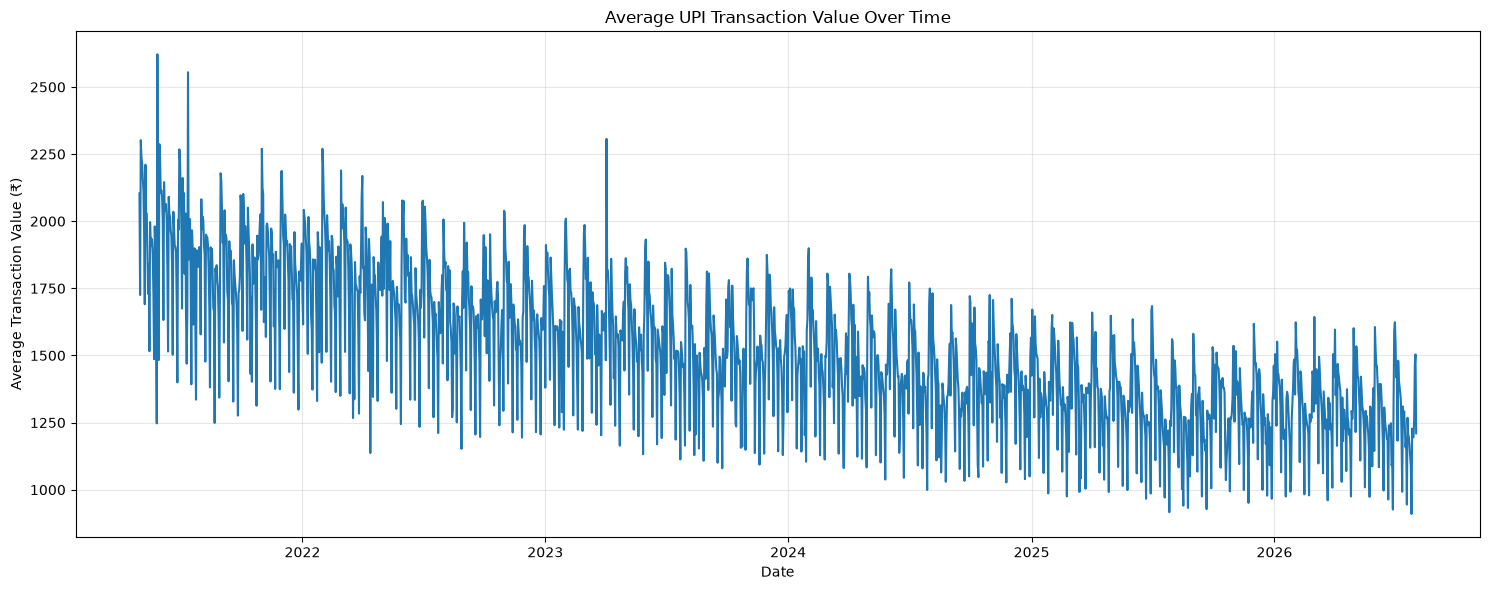

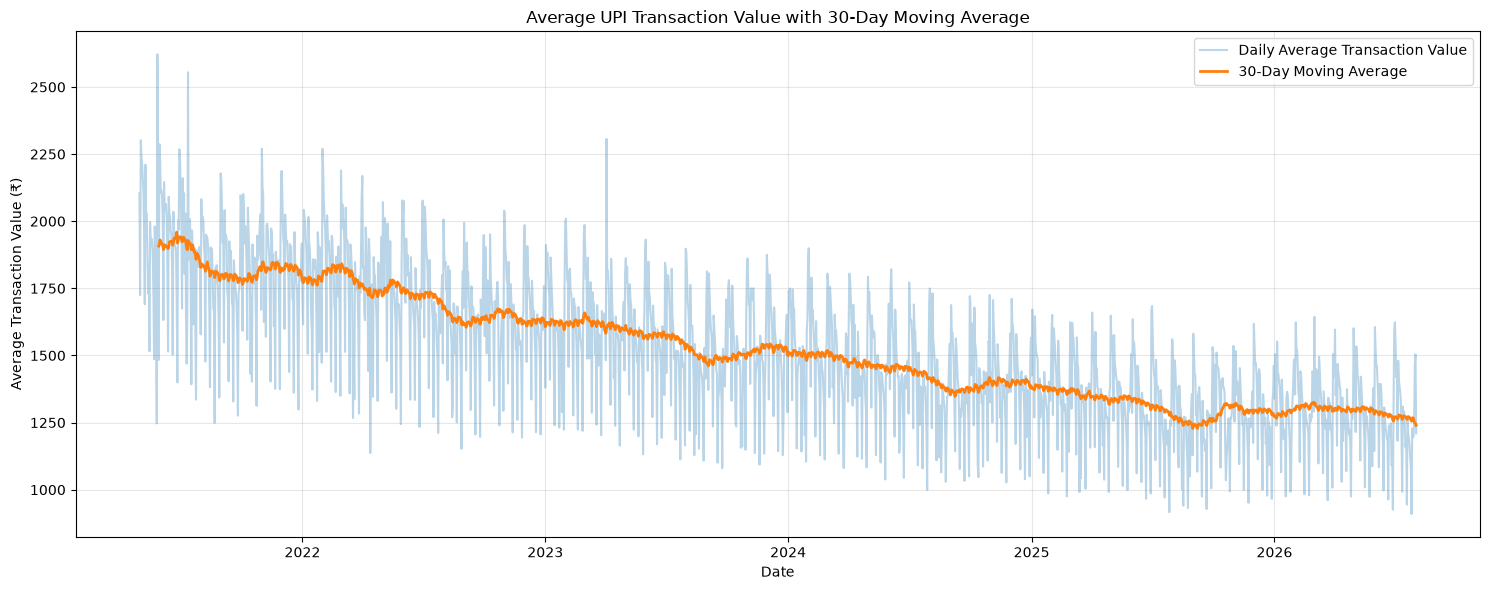


Yearly average transaction value:
   Year  Avg_Transaction_Value
0  2021            1843.808349
1  2022            1704.009405
2  2023            1556.089326
3  2024            1434.004904
4  2025            1312.482150
5  2026            1290.648982


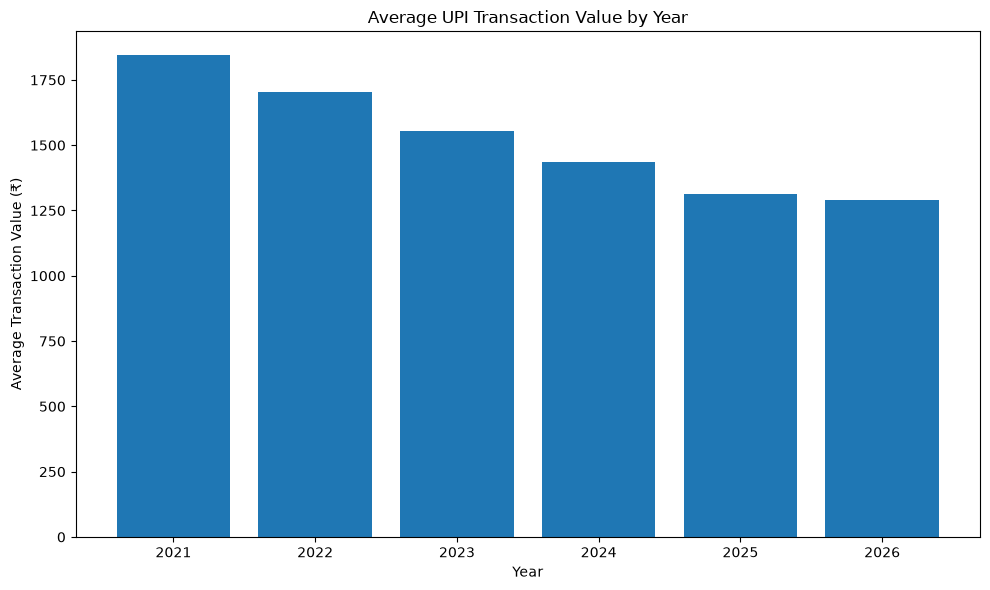


Year-over-year change in average transaction value:
   Year  Avg_Transaction_Value  Growth_%
0  2021            1843.808349       NaN
1  2022            1704.009405 -7.582076
2  2023            1556.089326 -8.680708
3  2024            1434.004904 -7.845592
4  2025            1312.482150 -8.474361
5  2026            1290.648982 -1.663502


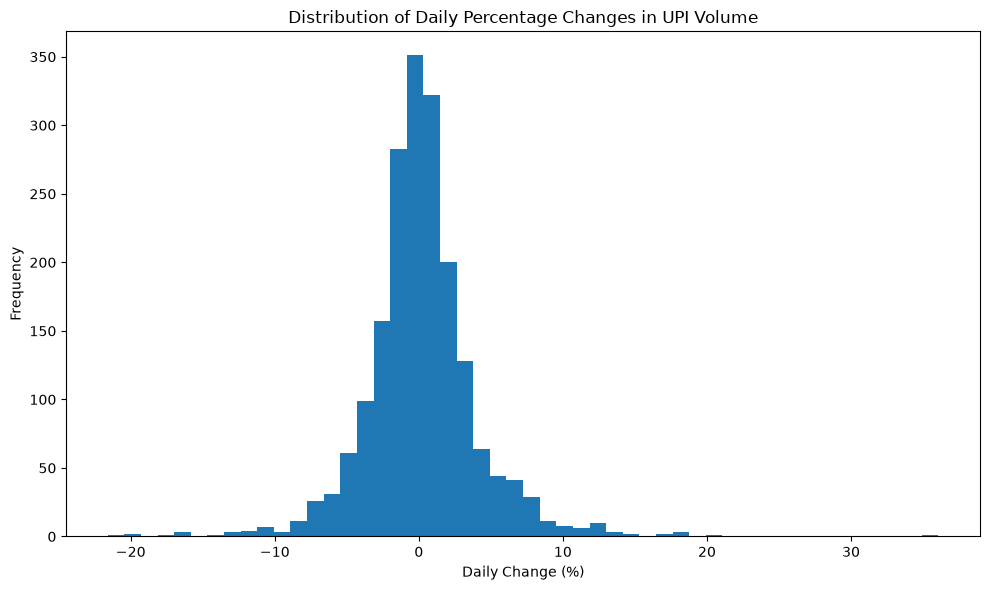

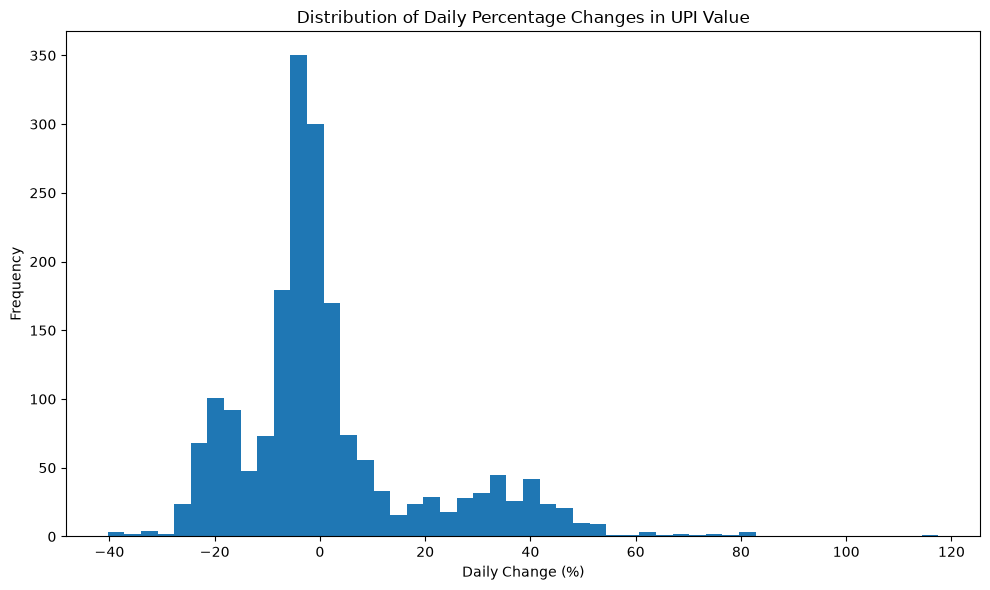


DAILY VOLATILITY

Volume daily-change standard deviation:
3.882871824237974

Value daily-change standard deviation:
18.256933163891766

TOP 10 DAILY VOLUME INCREASES
            Day  Volume (In Mn.)  Volume_Daily_Change_%
254  2022-01-10           165.05              36.067601
828  2023-08-07           359.11              20.180048
299  2022-02-24           167.92              18.153673
1279 2024-10-31           644.12              17.871390
30   2021-05-31            90.66              17.786150
426  2022-07-01           211.04              17.322660
1432 2025-04-02           619.27              16.905157
79   2021-07-19           104.95              14.686919
44   2021-06-14            97.37              14.324293
170  2021-10-18           134.79              13.737237

TOP 10 DAILY VOLUME DECREASES
            Day  Volume (In Mn.)  Volume_Daily_Change_%
253  2022-01-09           121.30             -21.595243
1413 2025-03-14           514.99             -19.795982
1280 2024-11-01   

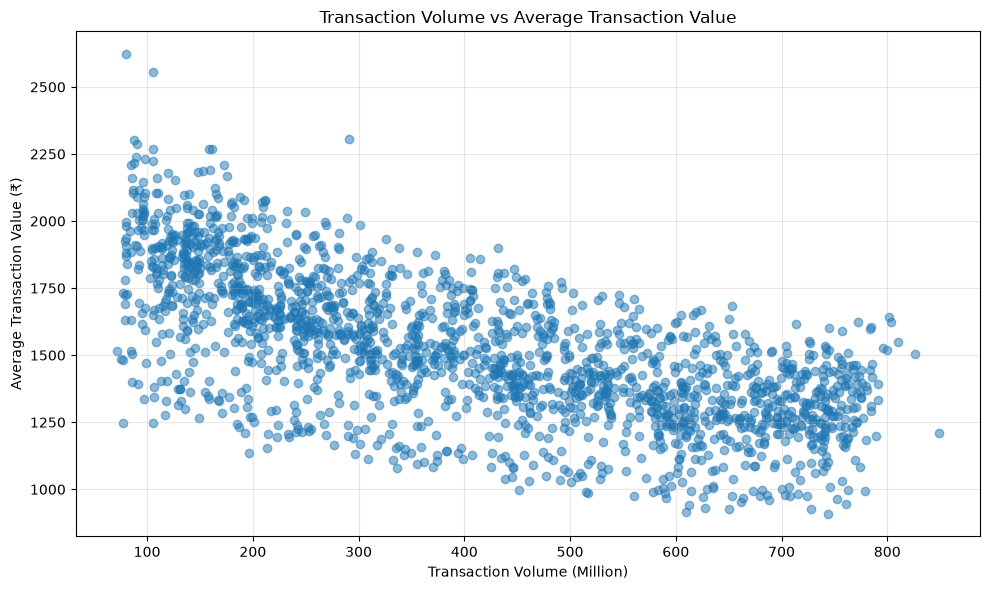


EXTENDED CORRELATION MATRIX
                       Volume (In Mn.)  Value (In Cr.)  Avg_Transaction_Value
Volume (In Mn.)               1.000000        0.951459              -0.678480
Value (In Cr.)                0.951459        1.000000              -0.465805
Avg_Transaction_Value        -0.678480       -0.465805               1.000000

COEFFICIENT OF VARIATION
Volume CV: 51.56676205357298 %
Value CV: 44.56135870288503 %
Average Transaction Value CV: 17.574666174585417 %


In [4]:
# ============================================================
# EDA STAGE 3
# TRANSACTION CHARACTERISTICS & DEEPER ANALYSIS
# ============================================================


# ============================================================
# 1. AVERAGE TRANSACTION VALUE
# ============================================================

df["Avg_Transaction_Value"] = (
    df["Value (In Cr.)"] / df["Volume (In Mn.)"]
) * 10

print("\n" + "=" * 60)
print("AVERAGE TRANSACTION VALUE")
print("=" * 60)

print("\nDescriptive statistics:")
print(df["Avg_Transaction_Value"].describe())


# ============================================================
# 2. AVERAGE TRANSACTION VALUE — TIME TREND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    df["Day"],
    df["Avg_Transaction_Value"]
)

plt.title("Average UPI Transaction Value Over Time")
plt.xlabel("Date")
plt.ylabel("Average Transaction Value (₹)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3. 30-DAY MOVING AVERAGE OF TRANSACTION SIZE
# ============================================================

df["Avg_Transaction_Value_30D_MA"] = (
    df["Avg_Transaction_Value"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    df["Day"],
    df["Avg_Transaction_Value"],
    alpha=0.3,
    label="Daily Average Transaction Value"
)

plt.plot(
    df["Day"],
    df["Avg_Transaction_Value_30D_MA"],
    linewidth=2,
    label="30-Day Moving Average"
)

plt.title("Average UPI Transaction Value with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Average Transaction Value (₹)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 4. YEARLY AVERAGE TRANSACTION VALUE
# ============================================================

yearly_transaction_size = (
    df.groupby("Year")["Avg_Transaction_Value"]
      .mean()
      .reset_index()
)

print("\nYearly average transaction value:")
print(yearly_transaction_size)


# ============================================================
# 5. YEARLY TRANSACTION SIZE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    yearly_transaction_size["Year"].astype(str),
    yearly_transaction_size["Avg_Transaction_Value"]
)

plt.title("Average UPI Transaction Value by Year")
plt.xlabel("Year")
plt.ylabel("Average Transaction Value (₹)")

plt.tight_layout()
plt.show()


# ============================================================
# 6. YEAR-OVER-YEAR CHANGE IN TRANSACTION SIZE
# ============================================================

yearly_transaction_size["Growth_%"] = (
    yearly_transaction_size["Avg_Transaction_Value"]
    .pct_change() * 100
)

print("\nYear-over-year change in average transaction value:")
print(yearly_transaction_size)


# ============================================================
# 7. DAILY PERCENTAGE CHANGE — VOLUME
# ============================================================

df["Volume_Daily_Change_%"] = (
    df["Volume (In Mn.)"]
    .pct_change() * 100
)


# ============================================================
# 8. DAILY PERCENTAGE CHANGE — VALUE
# ============================================================

df["Value_Daily_Change_%"] = (
    df["Value (In Cr.)"]
    .pct_change() * 100
)


# ============================================================
# 9. DISTRIBUTION OF DAILY CHANGES
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Volume_Daily_Change_%"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Percentage Changes in UPI Volume")
plt.xlabel("Daily Change (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.hist(
    df["Value_Daily_Change_%"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Percentage Changes in UPI Value")
plt.xlabel("Daily Change (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 10. VOLATILITY
# ============================================================

print("\n" + "=" * 60)
print("DAILY VOLATILITY")
print("=" * 60)

print("\nVolume daily-change standard deviation:")
print(df["Volume_Daily_Change_%"].std())

print("\nValue daily-change standard deviation:")
print(df["Value_Daily_Change_%"].std())


# ============================================================
# 11. LARGEST DAILY INCREASES — VOLUME
# ============================================================

largest_volume_increases = (
    df.nlargest(10, "Volume_Daily_Change_%")
      [["Day", "Volume (In Mn.)", "Volume_Daily_Change_%"]]
)

print("\n" + "=" * 60)
print("TOP 10 DAILY VOLUME INCREASES")
print("=" * 60)

print(largest_volume_increases)


# ============================================================
# 12. LARGEST DAILY DECREASES — VOLUME
# ============================================================

largest_volume_decreases = (
    df.nsmallest(10, "Volume_Daily_Change_%")
      [["Day", "Volume (In Mn.)", "Volume_Daily_Change_%"]]
)

print("\n" + "=" * 60)
print("TOP 10 DAILY VOLUME DECREASES")
print("=" * 60)

print(largest_volume_decreases)


# ============================================================
# 13. LARGEST DAILY INCREASES — VALUE
# ============================================================

largest_value_increases = (
    df.nlargest(10, "Value_Daily_Change_%")
      [["Day", "Value (In Cr.)", "Value_Daily_Change_%"]]
)

print("\n" + "=" * 60)
print("TOP 10 DAILY VALUE INCREASES")
print("=" * 60)

print(largest_value_increases)


# ============================================================
# 14. LARGEST DAILY DECREASES — VALUE
# ============================================================

largest_value_decreases = (
    df.nsmallest(10, "Value_Daily_Change_%")
      [["Day", "Value (In Cr.)", "Value_Daily_Change_%"]]
)

print("\n" + "=" * 60)
print("TOP 10 DAILY VALUE DECREASES")
print("=" * 60)

print(largest_value_decreases)


# ============================================================
# 15. IQR-BASED ANOMALY CHECK ON DAILY CHANGES
# ============================================================

print("\n" + "=" * 60)
print("ANOMALY CHECK — DAILY CHANGES")
print("=" * 60)


def find_change_anomalies(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    anomalies = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of anomalies:", len(anomalies))

    return anomalies


volume_change_anomalies = find_change_anomalies(
    "Volume_Daily_Change_%"
)

value_change_anomalies = find_change_anomalies(
    "Value_Daily_Change_%"
)


# ============================================================
# 16. TOP ANOMALOUS VOLUME MOVEMENTS
# ============================================================

print("\nTop anomalous volume movements:")

print(
    volume_change_anomalies[
        [
            "Day",
            "Volume (In Mn.)",
            "Volume_Daily_Change_%"
        ]
    ]
    .sort_values(
        "Volume_Daily_Change_%",
        ascending=False
    )
)


# ============================================================
# 17. TOP ANOMALOUS VALUE MOVEMENTS
# ============================================================

print("\nTop anomalous value movements:")

print(
    value_change_anomalies[
        [
            "Day",
            "Value (In Cr.)",
            "Value_Daily_Change_%"
        ]
    ]
    .sort_values(
        "Value_Daily_Change_%",
        ascending=False
    )
)


# ============================================================
# 18. RELATIONSHIP: TRANSACTION SIZE VS VOLUME
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Volume (In Mn.)"],
    df["Avg_Transaction_Value"],
    alpha=0.5
)

plt.title(
    "Transaction Volume vs Average Transaction Value"
)

plt.xlabel("Transaction Volume (Million)")
plt.ylabel("Average Transaction Value (₹)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 19. CORRELATION MATRIX — EXTENDED
# ============================================================

extended_correlation = df[
    [
        "Volume (In Mn.)",
        "Value (In Cr.)",
        "Avg_Transaction_Value"
    ]
].corr()

print("\n" + "=" * 60)
print("EXTENDED CORRELATION MATRIX")
print("=" * 60)

print(extended_correlation)


# ============================================================
# 20. COEFFICIENT OF VARIATION
# ============================================================

volume_cv = (
    df["Volume (In Mn.)"].std()
    / df["Volume (In Mn.)"].mean()
) * 100

value_cv = (
    df["Value (In Cr.)"].std()
    / df["Value (In Cr.)"].mean()
) * 100

transaction_size_cv = (
    df["Avg_Transaction_Value"].std()
    / df["Avg_Transaction_Value"].mean()
) * 100

print("\n" + "=" * 60)
print("COEFFICIENT OF VARIATION")
print("=" * 60)

print("Volume CV:", volume_cv, "%")
print("Value CV:", value_cv, "%")
print(
    "Average Transaction Value CV:",
    transaction_size_cv,
    "%"
)




ANOMALIES BY DAY OF WEEK

Volume anomalies:
Day_of_Week
Monday       37
Tuesday      17
Wednesday    19
Thursday     13
Friday       15
Saturday     19
Sunday       23
Name: Volume_Anomaly, dtype: int64

Value anomalies:
Day_of_Week
Monday       244
Tuesday        8
Wednesday      9
Thursday       9
Friday         9
Saturday       4
Sunday        12
Name: Value_Anomaly, dtype: int64

WEEKDAY VS WEEKEND ANOMALY RATE
         Total_Days  Volume_Anomalies  Value_Anomalies  Volume_Anomaly_Rate_%  \
Weekend                                                                         
False          1370               101              279               7.372263   
True            550                42               16               7.636364   

         Value_Anomaly_Rate_%  
Weekend                        
False               20.364964  
True                 2.909091  

MONTH-BOUNDARY ANOMALY ANALYSIS
                       Period  Total_Days  Volume_Anomalies  Value_Anomalies  \
0  Month Start

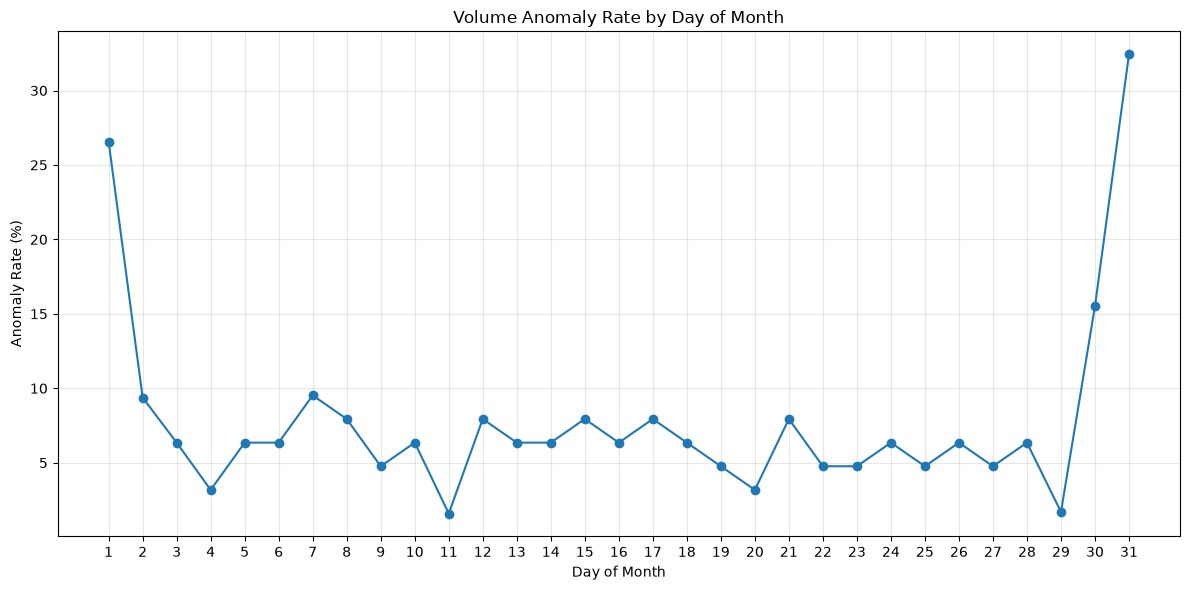

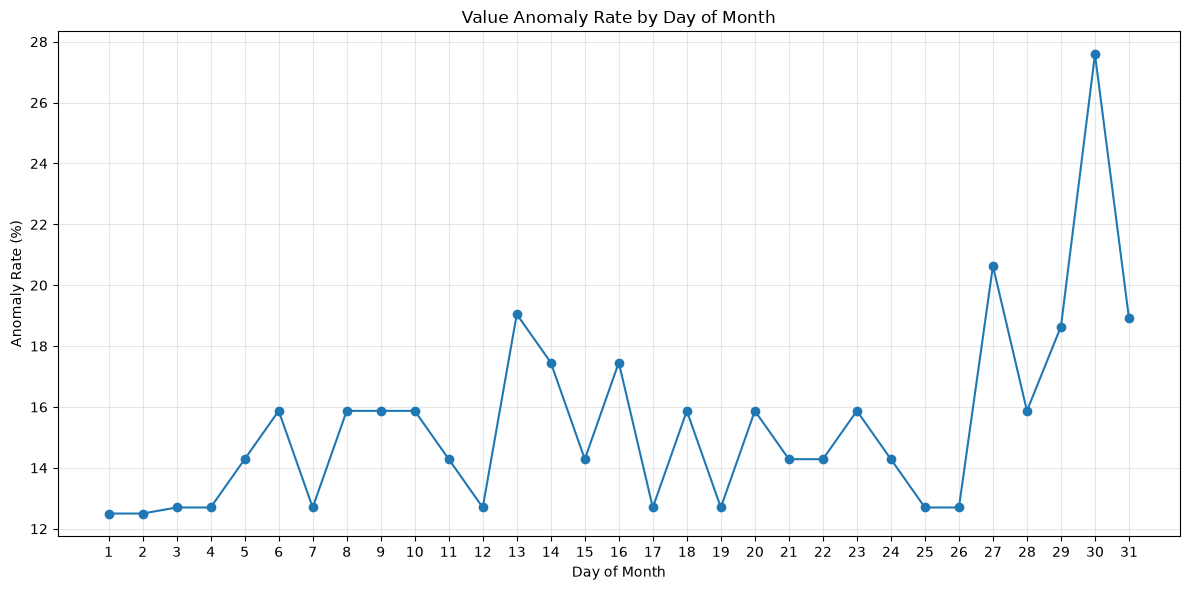


ANOMALIES BY YEAR
      Total_Days  Volume_Anomalies  Value_Anomalies  Volume_Anomaly_Rate_%  \
Year                                                                         
2021         245                42               49              17.142857   
2022         365                37               59              10.136986   
2023         365                24               56               6.575342   
2024         366                16               47               4.371585   
2025         365                18               53               4.931507   
2026         214                 6               31               2.803738   

      Value_Anomaly_Rate_%  
Year                        
2021             20.000000  
2022             16.164384  
2023             15.342466  
2024             12.841530  
2025             14.520548  
2026             14.485981  

TOP VOLUME ANOMALIES
            Day Day_of_Week  Day_of_Month  Month_Start  Month_End  Weekend  \
254  2022-01-10      Mon

In [5]:
# ============================================================
# EDA STAGE 3B
# ANOMALY / DATE-PATTERN INVESTIGATION
# ============================================================


# ============================================================
# 21. CREATE CALENDAR FEATURES
# ============================================================

df["Day_of_Month"] = df["Day"].dt.day
df["Days_in_Month"] = df["Day"].dt.days_in_month

# Is the date near the beginning of the month?
df["Month_Start"] = df["Day_of_Month"] <= 3

# Is the date near the end of the month?
df["Month_End"] = (
    df["Day_of_Month"] >= df["Days_in_Month"] - 2
)

# Weekend indicator
df["Weekend"] = df["Day"].dt.dayofweek >= 5


# ============================================================
# 22. ANOMALY FLAGS
# ============================================================

# Use the anomalies already calculated in Stage 3

df["Volume_Anomaly"] = df.index.isin(
    volume_change_anomalies.index
)

df["Value_Anomaly"] = df.index.isin(
    value_change_anomalies.index
)


# ============================================================
# 23. ANOMALY COUNTS BY DAY OF WEEK
# ============================================================

volume_anomalies_weekday = (
    df[df["Volume_Anomaly"]]
    .groupby("Day_of_Week")["Volume_Anomaly"]
    .count()
    .reindex(weekday_names)
)

value_anomalies_weekday = (
    df[df["Value_Anomaly"]]
    .groupby("Day_of_Week")["Value_Anomaly"]
    .count()
    .reindex(weekday_names)
)

print("\n" + "=" * 60)
print("ANOMALIES BY DAY OF WEEK")
print("=" * 60)

print("\nVolume anomalies:")
print(volume_anomalies_weekday)

print("\nValue anomalies:")
print(value_anomalies_weekday)


# ============================================================
# 24. ANOMALY COUNTS — WEEKDAY VS WEEKEND
# ============================================================

weekend_anomalies = df.groupby("Weekend").agg(
    Total_Days=("Day", "count"),
    Volume_Anomalies=("Volume_Anomaly", "sum"),
    Value_Anomalies=("Value_Anomaly", "sum")
)

weekend_anomalies["Volume_Anomaly_Rate_%"] = (
    weekend_anomalies["Volume_Anomalies"]
    / weekend_anomalies["Total_Days"]
    * 100
)

weekend_anomalies["Value_Anomaly_Rate_%"] = (
    weekend_anomalies["Value_Anomalies"]
    / weekend_anomalies["Total_Days"]
    * 100
)

print("\n" + "=" * 60)
print("WEEKDAY VS WEEKEND ANOMALY RATE")
print("=" * 60)

print(weekend_anomalies)


# ============================================================
# 25. ANOMALIES AROUND MONTH BOUNDARIES
# ============================================================

month_boundary_analysis = pd.DataFrame({
    "Period": [
        "Month Start (First 3 Days)",
        "Month End (Last 3 Days)",
        "Other Days"
    ],

    "Total_Days": [
        df["Month_Start"].sum(),
        df["Month_End"].sum(),
        (~df["Month_Start"] & ~df["Month_End"]).sum()
    ],

    "Volume_Anomalies": [
        df.loc[df["Month_Start"], "Volume_Anomaly"].sum(),
        df.loc[df["Month_End"], "Volume_Anomaly"].sum(),
        df.loc[
            ~df["Month_Start"] & ~df["Month_End"],
            "Volume_Anomaly"
        ].sum()
    ],

    "Value_Anomalies": [
        df.loc[df["Month_Start"], "Value_Anomaly"].sum(),
        df.loc[df["Month_End"], "Value_Anomaly"].sum(),
        df.loc[
            ~df["Month_Start"] & ~df["Month_End"],
            "Value_Anomaly"
        ].sum()
    ]
})

month_boundary_analysis["Volume_Anomaly_Rate_%"] = (
    month_boundary_analysis["Volume_Anomalies"]
    / month_boundary_analysis["Total_Days"]
    * 100
)

month_boundary_analysis["Value_Anomaly_Rate_%"] = (
    month_boundary_analysis["Value_Anomalies"]
    / month_boundary_analysis["Total_Days"]
    * 100
)

print("\n" + "=" * 60)
print("MONTH-BOUNDARY ANOMALY ANALYSIS")
print("=" * 60)

print(month_boundary_analysis)


# ============================================================
# 26. ANOMALIES BY DAY OF MONTH
# ============================================================

day_of_month_anomalies = (
    df.groupby("Day_of_Month")
      .agg(
          Total_Days=("Day", "count"),
          Volume_Anomalies=("Volume_Anomaly", "sum"),
          Value_Anomalies=("Value_Anomaly", "sum")
      )
)

day_of_month_anomalies["Volume_Anomaly_Rate_%"] = (
    day_of_month_anomalies["Volume_Anomalies"]
    / day_of_month_anomalies["Total_Days"]
    * 100
)

day_of_month_anomalies["Value_Anomaly_Rate_%"] = (
    day_of_month_anomalies["Value_Anomalies"]
    / day_of_month_anomalies["Total_Days"]
    * 100
)

print("\n" + "=" * 60)
print("ANOMALIES BY DAY OF MONTH")
print("=" * 60)

print(day_of_month_anomalies)


# ============================================================
# 27. PLOT ANOMALY RATE BY DAY OF MONTH — VOLUME
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    day_of_month_anomalies.index,
    day_of_month_anomalies["Volume_Anomaly_Rate_%"],
    marker="o"
)

plt.title("Volume Anomaly Rate by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(range(1, 32))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 28. PLOT ANOMALY RATE BY DAY OF MONTH — VALUE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    day_of_month_anomalies.index,
    day_of_month_anomalies["Value_Anomaly_Rate_%"],
    marker="o"
)

plt.title("Value Anomaly Rate by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(range(1, 32))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 29. ANOMALIES BY YEAR
# ============================================================

yearly_anomalies = (
    df.groupby("Year")
      .agg(
          Total_Days=("Day", "count"),
          Volume_Anomalies=("Volume_Anomaly", "sum"),
          Value_Anomalies=("Value_Anomaly", "sum")
      )
)

yearly_anomalies["Volume_Anomaly_Rate_%"] = (
    yearly_anomalies["Volume_Anomalies"]
    / yearly_anomalies["Total_Days"]
    * 100
)

yearly_anomalies["Value_Anomaly_Rate_%"] = (
    yearly_anomalies["Value_Anomalies"]
    / yearly_anomalies["Total_Days"]
    * 100
)

print("\n" + "=" * 60)
print("ANOMALIES BY YEAR")
print("=" * 60)

print(yearly_anomalies)


# ============================================================
# 30. TOP ANOMALOUS DAYS WITH CALENDAR INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("TOP VOLUME ANOMALIES")
print("=" * 60)

print(
    df[df["Volume_Anomaly"]][
        [
            "Day",
            "Day_of_Week",
            "Day_of_Month",
            "Month_Start",
            "Month_End",
            "Weekend",
            "Volume (In Mn.)",
            "Volume_Daily_Change_%"
        ]
    ]
    .sort_values(
        "Volume_Daily_Change_%",
        ascending=False
    )
    .head(20)
)


print("\n" + "=" * 60)
print("TOP VALUE ANOMALIES")
print("=" * 60)

print(
    df[df["Value_Anomaly"]][
        [
            "Day",
            "Day_of_Week",
            "Day_of_Month",
            "Month_Start",
            "Month_End",
            "Weekend",
            "Value (In Cr.)",
            "Value_Daily_Change_%"
        ]
    ]
    .sort_values(
        "Value_Daily_Change_%",
        ascending=False
    )
    .head(20)
)

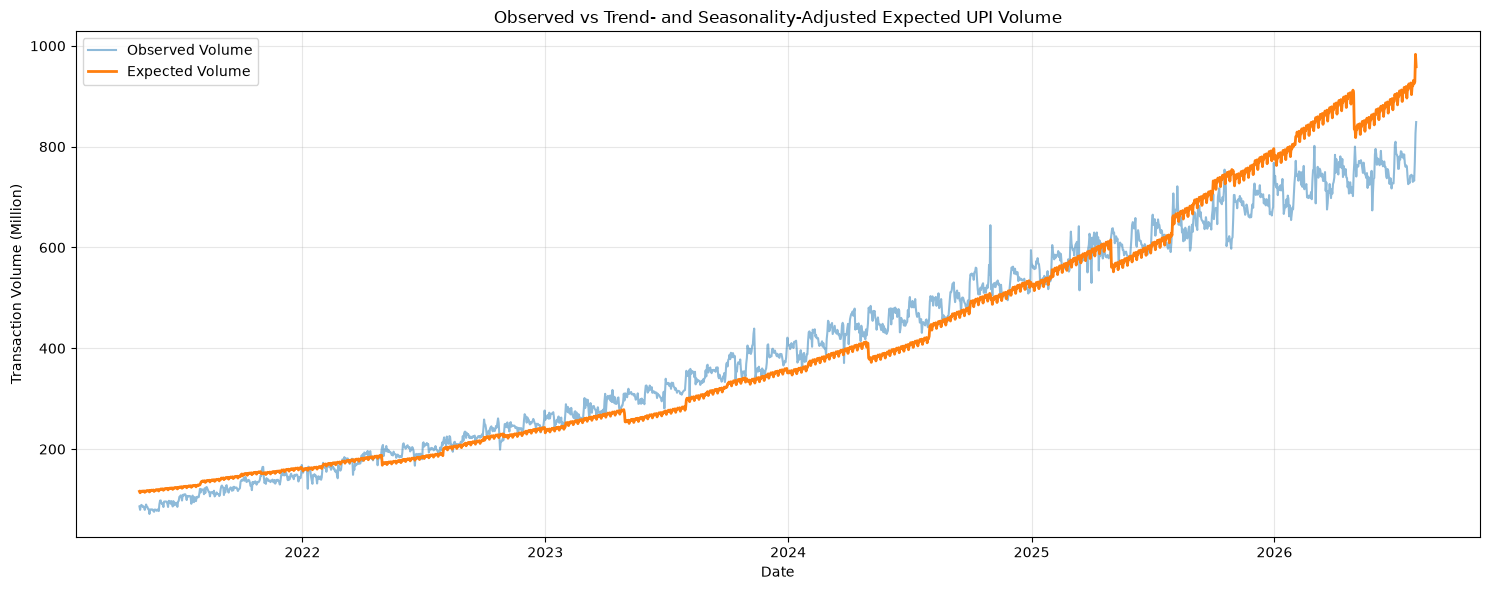

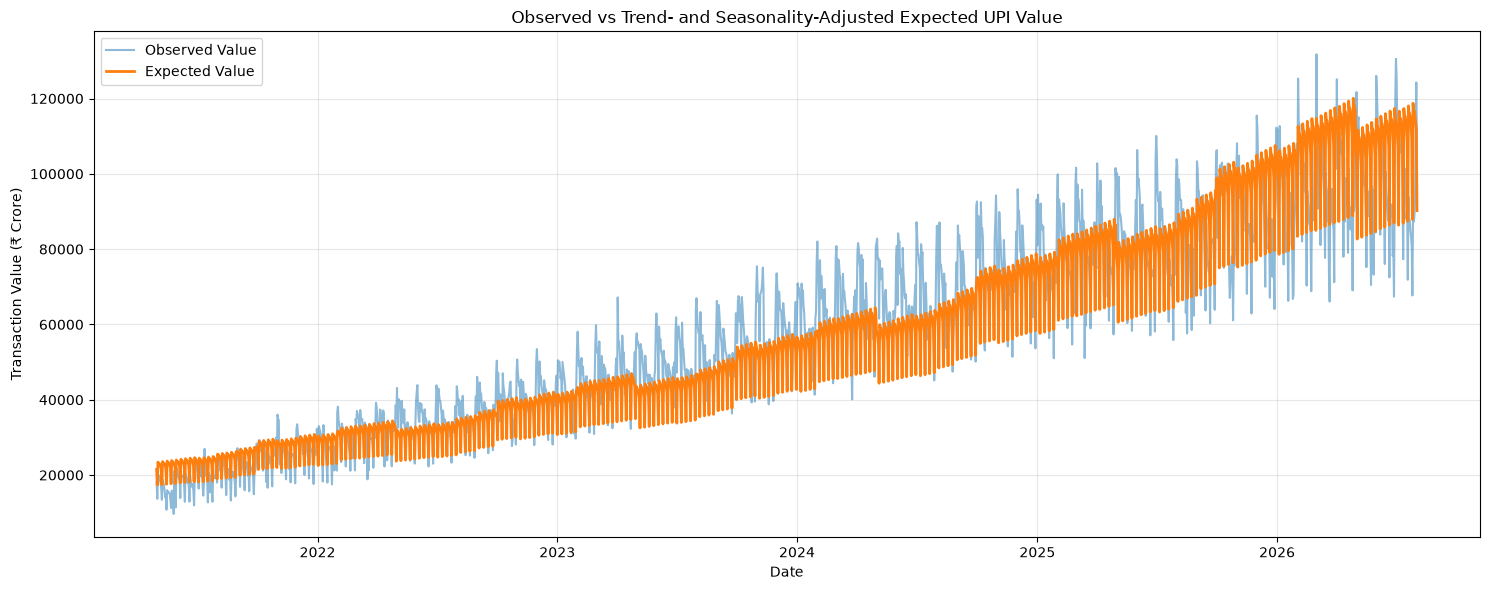

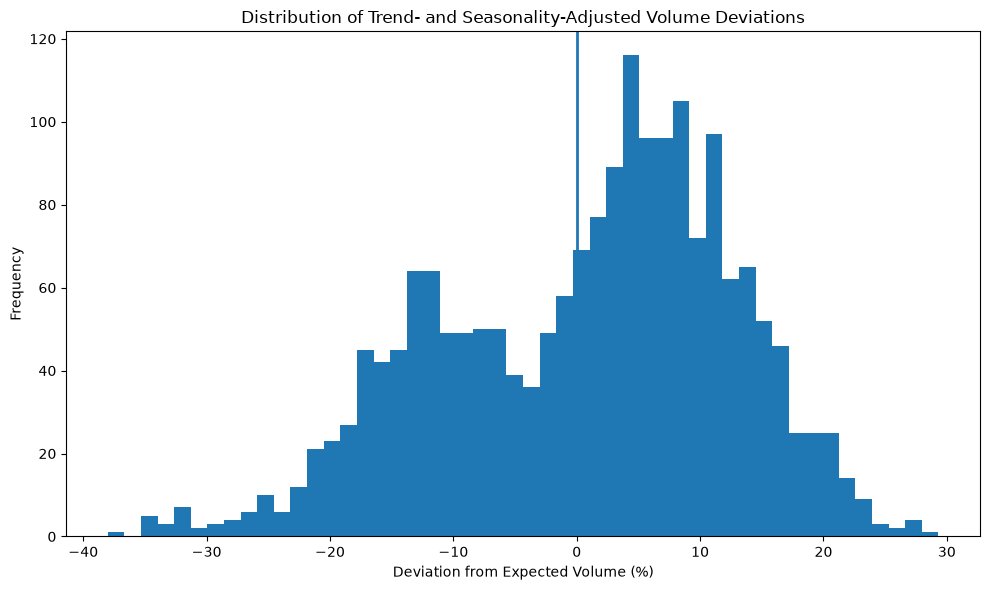

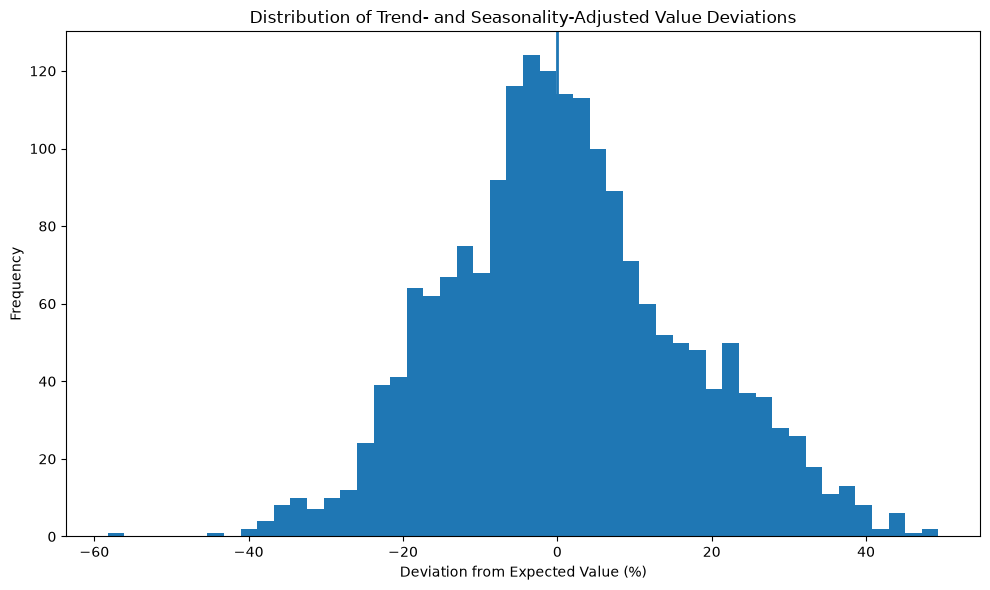


------------------------------------------------------------
Volume_Adjusted_Deviation_%
------------------------------------------------------------
Q1: -8.521782941248121
Q3: 9.671827163919339
IQR: 18.19361010516746
Lower bound: -35.81219809899931
Upper bound: 36.96224232167053
Number of potential anomalies: 1

------------------------------------------------------------
Value_Adjusted_Deviation_%
------------------------------------------------------------
Q1: -9.134989964990334
Q3: 10.792606265517374
IQR: 19.92759623050771
Lower bound: -39.0263843107519
Upper bound: 40.68400061127894
Number of potential anomalies: 15

TOP ADJUSTED VOLUME ANOMALIES
          Day Day_of_Week  Month  Volume (In Mn.)  Expected_Volume  \
15 2021-05-16      Sunday      5            71.28       114.996245   

    Volume_Adjusted_Deviation_%  
15                   -38.015367  

TOP ADJUSTED VALUE ANOMALIES
            Day Day_of_Week  Month  Value (In Cr.)  Expected_Value  \
365  2022-05-01      Sunday   

In [6]:
# ============================================================
# EDA STAGE 3C
# TREND + SEASONALITY ADJUSTED ANOMALY DETECTION
# ============================================================


# ============================================================
# 31. PREPARE TIME VARIABLE
# ============================================================

# Number of days since the beginning of the dataset
df["Time_Index"] = (
    df["Day"] - df["Day"].min()
).dt.days


# ============================================================
# 32. FUNCTION FOR TREND + SEASONALITY MODEL
# ============================================================

def calculate_adjusted_anomalies(df, value_column):

    # --------------------------------------------------------
    # Log transformation
    # --------------------------------------------------------
    # Helps model the approximately multiplicative growth
    # in UPI activity over time.

    y = np.log(df[value_column].values)

    # --------------------------------------------------------
    # Create explanatory variables
    # --------------------------------------------------------

    time = df["Time_Index"].values

    # Normalize time to make numerical calculations stable
    time_normalized = (
        time - time.mean()
    ) / time.std()

    # Month dummy variables
    month_dummies = pd.get_dummies(
        df["Month"],
        prefix="Month",
        drop_first=True
    ).astype(float)

    # Day-of-week dummy variables
    weekday_dummies = pd.get_dummies(
        df["Day_of_Week_Num"],
        prefix="Weekday",
        drop_first=True
    ).astype(float)

    # Combine variables
    X = pd.concat(
        [
            pd.Series(
                np.ones(len(df)),
                name="Intercept"
            ),
            pd.Series(
                time_normalized,
                name="Time"
            ),
            month_dummies.reset_index(drop=True),
            weekday_dummies.reset_index(drop=True)
        ],
        axis=1
    )

    # --------------------------------------------------------
    # Fit linear model using least squares
    # --------------------------------------------------------

    X_matrix = X.values

    coefficients = np.linalg.lstsq(
        X_matrix,
        y,
        rcond=None
    )[0]

    # Predicted log value
    predicted_log = X_matrix @ coefficients

    # Convert back to original scale
    predicted_value = np.exp(predicted_log)

    # --------------------------------------------------------
    # Calculate residual
    # --------------------------------------------------------

    residual = y - predicted_log

    # Convert log residual into percentage deviation
    percentage_deviation = (
        (np.exp(residual) - 1) * 100
    )

    return predicted_value, residual, percentage_deviation


# ============================================================
# 33. ADJUSTED VOLUME
# ============================================================

(
    df["Expected_Volume"],
    df["Volume_Residual"],
    df["Volume_Adjusted_Deviation_%"]
) = calculate_adjusted_anomalies(
    df,
    "Volume (In Mn.)"
)


# ============================================================
# 34. ADJUSTED VALUE
# ============================================================

(
    df["Expected_Value"],
    df["Value_Residual"],
    df["Value_Adjusted_Deviation_%"]
) = calculate_adjusted_anomalies(
    df,
    "Value (In Cr.)"
)


# ============================================================
# 35. OBSERVED VS EXPECTED VOLUME
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    df["Day"],
    df["Volume (In Mn.)"],
    alpha=0.5,
    label="Observed Volume"
)

plt.plot(
    df["Day"],
    df["Expected_Volume"],
    linewidth=2,
    label="Expected Volume"
)

plt.title(
    "Observed vs Trend- and Seasonality-Adjusted Expected UPI Volume"
)

plt.xlabel("Date")
plt.ylabel("Transaction Volume (Million)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 36. OBSERVED VS EXPECTED VALUE
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    df["Day"],
    df["Value (In Cr.)"],
    alpha=0.5,
    label="Observed Value"
)

plt.plot(
    df["Day"],
    df["Expected_Value"],
    linewidth=2,
    label="Expected Value"
)

plt.title(
    "Observed vs Trend- and Seasonality-Adjusted Expected UPI Value"
)

plt.xlabel("Date")
plt.ylabel("Transaction Value (₹ Crore)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 37. DISTRIBUTION OF ADJUSTED VOLUME DEVIATIONS
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Volume_Adjusted_Deviation_%"],
    bins=50
)

plt.axvline(
    0,
    linewidth=2
)

plt.title(
    "Distribution of Trend- and Seasonality-Adjusted Volume Deviations"
)

plt.xlabel("Deviation from Expected Volume (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 38. DISTRIBUTION OF ADJUSTED VALUE DEVIATIONS
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Value_Adjusted_Deviation_%"],
    bins=50
)

plt.axvline(
    0,
    linewidth=2
)

plt.title(
    "Distribution of Trend- and Seasonality-Adjusted Value Deviations"
)

plt.xlabel("Deviation from Expected Value (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 39. IQR ANOMALY DETECTION ON ADJUSTED DEVIATIONS
# ============================================================

def adjusted_anomaly_detection(
    df,
    column
):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    anomalies = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ].copy()

    print("\n" + "-" * 60)
    print(column)
    print("-" * 60)

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of potential anomalies:", len(anomalies))

    return anomalies


volume_adjusted_anomalies = (
    adjusted_anomaly_detection(
        df,
        "Volume_Adjusted_Deviation_%"
    )
)

value_adjusted_anomalies = (
    adjusted_anomaly_detection(
        df,
        "Value_Adjusted_Deviation_%"
    )
)


# ============================================================
# 40. TOP ADJUSTED VOLUME ANOMALIES
# ============================================================

print("\n" + "=" * 60)
print("TOP ADJUSTED VOLUME ANOMALIES")
print("=" * 60)

print(
    volume_adjusted_anomalies[
        [
            "Day",
            "Day_of_Week",
            "Month",
            "Volume (In Mn.)",
            "Expected_Volume",
            "Volume_Adjusted_Deviation_%"
        ]
    ]
    .sort_values(
        "Volume_Adjusted_Deviation_%",
        ascending=False
    )
    .head(20)
)


# ============================================================
# 41. TOP ADJUSTED VALUE ANOMALIES
# ============================================================

print("\n" + "=" * 60)
print("TOP ADJUSTED VALUE ANOMALIES")
print("=" * 60)

print(
    value_adjusted_anomalies[
        [
            "Day",
            "Day_of_Week",
            "Month",
            "Value (In Cr.)",
            "Expected_Value",
            "Value_Adjusted_Deviation_%"
        ]
    ]
    .sort_values(
        "Value_Adjusted_Deviation_%",
        ascending=False
    )
    .head(20)
)


# ============================================================
# 42. ANOMALY COUNTS BY YEAR
# ============================================================

volume_adjusted_yearly = (
    volume_adjusted_anomalies
    .groupby("Year")
    .size()
)

value_adjusted_yearly = (
    value_adjusted_anomalies
    .groupby("Year")
    .size()
)

print("\n" + "=" * 60)
print("ADJUSTED ANOMALIES BY YEAR")
print("=" * 60)

print("\nVolume anomalies by year:")
print(volume_adjusted_yearly)

print("\nValue anomalies by year:")
print(value_adjusted_yearly)


# ============================================================
# 43. LARGEST POSITIVE / NEGATIVE DEVIATIONS
# ============================================================

print("\n" + "=" * 60)
print("EXTREME ADJUSTED DEVIATIONS")
print("=" * 60)

print("\nLargest positive volume deviations:")
print(
    df.nlargest(
        10,
        "Volume_Adjusted_Deviation_%"
    )[
        [
            "Day",
            "Volume (In Mn.)",
            "Expected_Volume",
            "Volume_Adjusted_Deviation_%"
        ]
    ]
)

print("\nLargest negative volume deviations:")
print(
    df.nsmallest(
        10,
        "Volume_Adjusted_Deviation_%"
    )[
        [
            "Day",
            "Volume (In Mn.)",
            "Expected_Volume",
            "Volume_Adjusted_Deviation_%"
        ]
    ]
)

print("\nLargest positive value deviations:")
print(
    df.nlargest(
        10,
        "Value_Adjusted_Deviation_%"
    )[
        [
            "Day",
            "Value (In Cr.)",
            "Expected_Value",
            "Value_Adjusted_Deviation_%"
        ]
    ]
)

print("\nLargest negative value deviations:")
print(
    df.nsmallest(
        10,
        "Value_Adjusted_Deviation_%"
    )[
        [
            "Day",
            "Value (In Cr.)",
            "Expected_Value",
            "Value_Adjusted_Deviation_%"
        ]
    ]
)


WEEKLY TIME-SERIES DECOMPOSITION - VOLUME

Trend component:
Day
2021-05-04    86.000000
2021-05-05    85.601429
2021-05-06    85.605714
2021-05-07    85.205714
2021-05-08    85.305714
Name: trend, dtype: float64

Seasonal component:
Day
2021-05-01    3.601234
2021-05-02   -3.943470
2021-05-03   -0.515579
2021-05-04   -2.077421
2021-05-05    2.652360
2021-05-06   -0.751753
2021-05-07    1.034630
2021-05-08    3.601234
2021-05-09   -3.943470
2021-05-10   -0.515579
2021-05-11   -2.077421
2021-05-12    2.652360
2021-05-13   -0.751753
2021-05-14    1.034630
Name: seasonal, dtype: float64

Residual component:
Day
2021-05-04    5.387421
2021-05-05   -0.553789
2021-05-06    0.496039
2021-05-07    0.069656
2021-05-08   -5.456948
Name: resid, dtype: float64


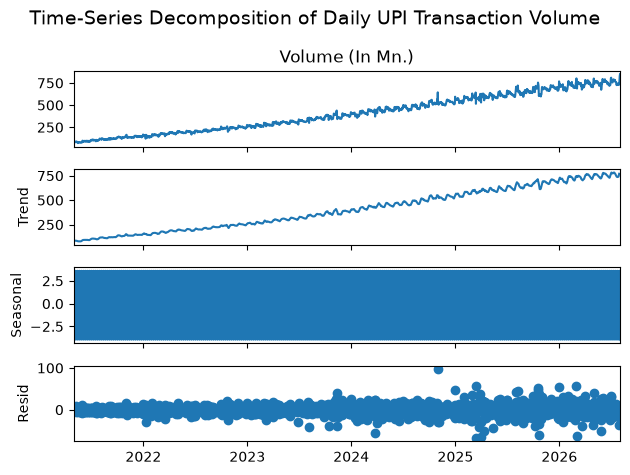


WEEKLY TIME-SERIES DECOMPOSITION - VALUE

Trend component:
Day
2021-05-04    18305.767143
2021-05-05    18052.224286
2021-05-06    18014.098571
2021-05-07    17811.404286
2021-05-08    17563.168571
Name: trend, dtype: float64

Seasonal component:
Day
2021-05-01     -742.049208
2021-05-02   -11460.599867
2021-05-03     4011.437166
2021-05-04     2611.935964
2021-05-05     2747.940829
2021-05-06     1890.307606
2021-05-07      941.027511
2021-05-08     -742.049208
2021-05-09   -11460.599867
2021-05-10     4011.437166
2021-05-11     2611.935964
2021-05-12     2747.940829
2021-05-13     1890.307606
2021-05-14      941.027511
Name: seasonal, dtype: float64

Residual component:
Day
2021-05-04    -912.683107
2021-05-05   -1362.015114
2021-05-06   -1478.726178
2021-05-07    -504.661797
2021-05-08    -455.709363
Name: resid, dtype: float64


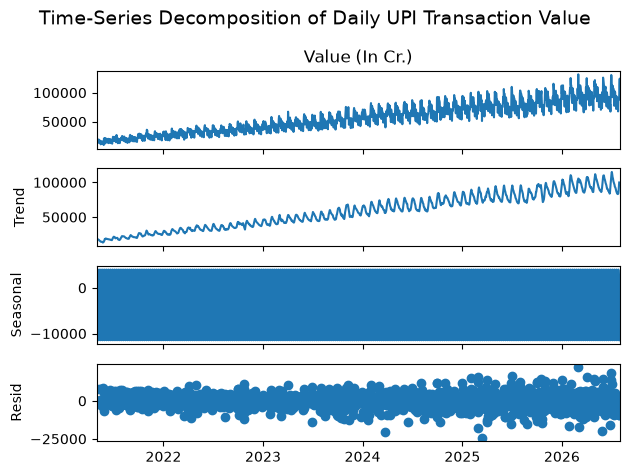


DECOMPOSITION SUMMARY

Volume:
Trend range: 78.32142857142857 to 782.9685714285713
Seasonal range: -3.943470454516931 to 3.6012338887588373
Residual standard deviation: 10.558018073009448

Value:
Trend range: 13269.05 to 115046.14285714284
Seasonal range: -11460.599867462346 to 4011.437165504687
Residual standard deviation: 4211.6624915728

WEEKLY SEASONAL EFFECT
  Day_of_Week  Volume_Seasonal_Effect  Value_Seasonal_Effect
0      Monday               -0.515579            4011.437166
1     Tuesday               -2.077421            2611.935964
2   Wednesday                2.652360            2747.940829
3    Thursday               -0.751753            1890.307606
4      Friday                1.034630             941.027511
5    Saturday                3.601234            -742.049208
6      Sunday               -3.943470          -11460.599867


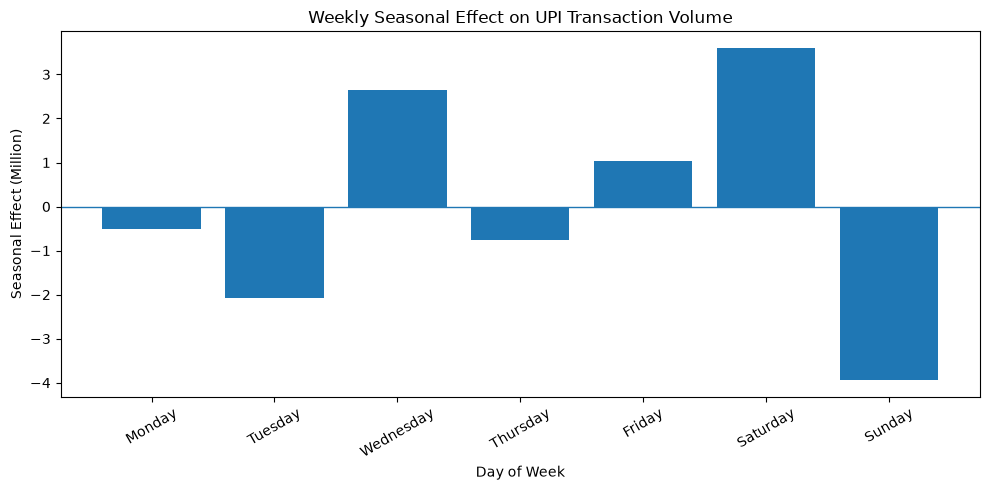

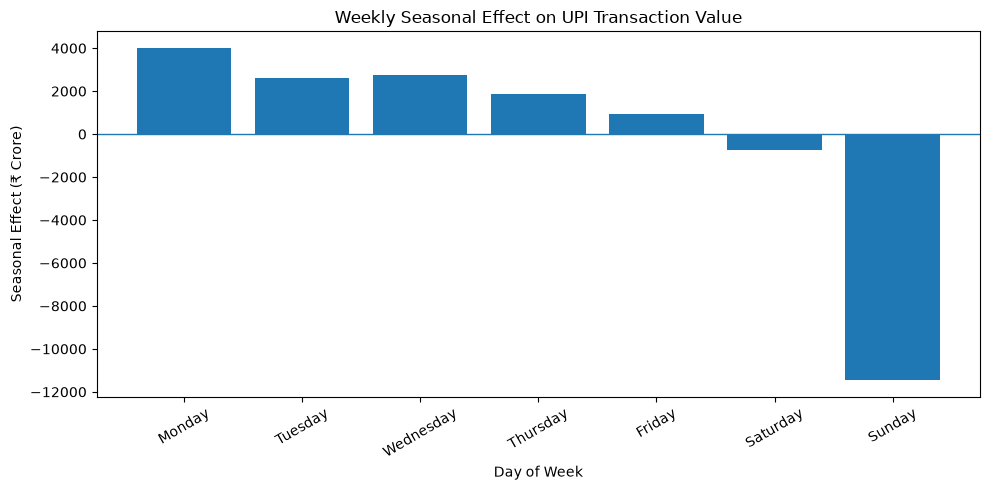

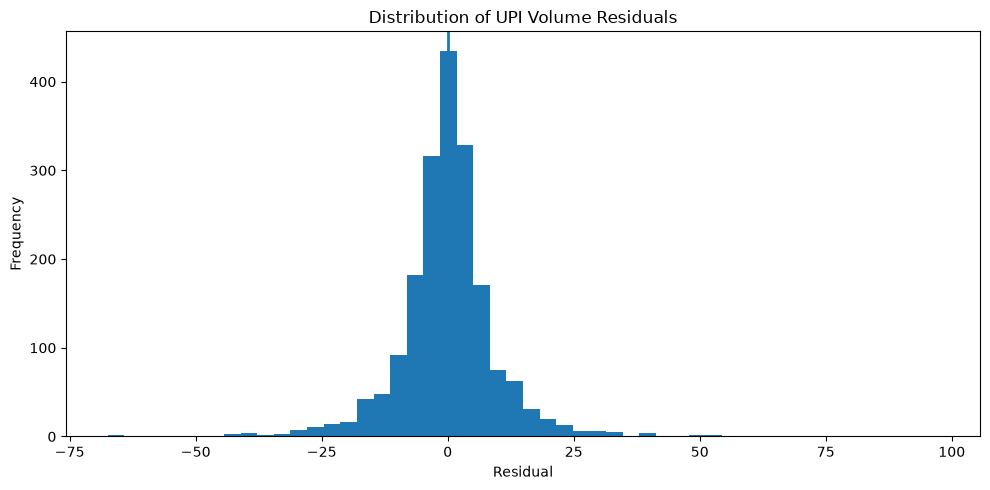

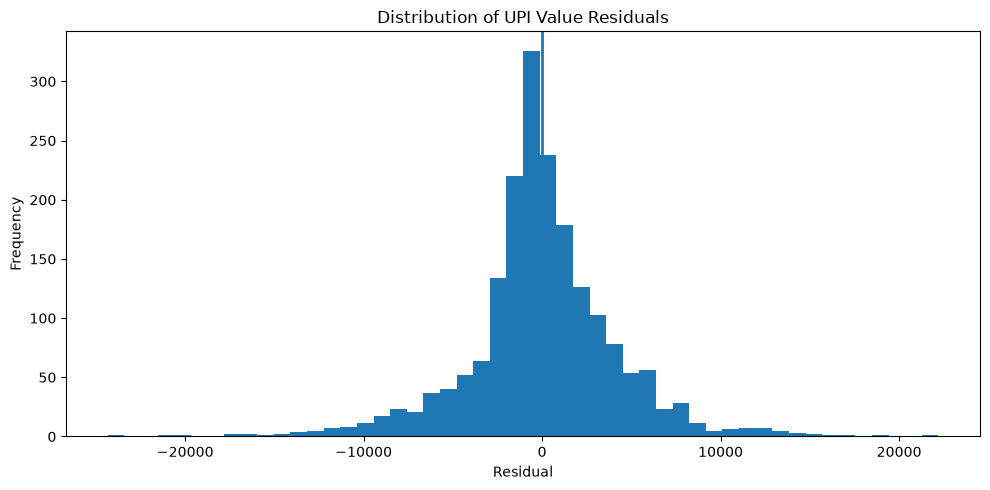


------------------------------------------------------------
Volume_Residual
------------------------------------------------------------
Q1: -4.351872603537256
Q3: 4.128383195581904
IQR: 8.48025579911916
Lower bound: -17.072256302215997
Upper bound: 16.848766894260642
Number of residual anomalies: 152

------------------------------------------------------------
Value_Residual
------------------------------------------------------------
Q1: -1718.1222596962016
Q3: 1999.5723674623505
IQR: 3717.694627158552
Lower bound: -7294.66420043403
Upper bound: 7576.114308200179
Number of residual anomalies: 159

TOP VOLUME RESIDUAL ANOMALIES
            Day Day_of_Week  Volume (In Mn.)  Volume_Trend  Volume_Seasonal  \
1279 2024-10-31    Thursday           644.12    547.514286        -0.751753   
1413 2025-03-14      Friday           514.99    581.411429         1.034630   
1431 2025-04-01     Tuesday           529.72    598.121429        -2.077421   
1768 2026-03-04   Wednesday           687.48

In [7]:
# ============================================================
# EDA STAGE 3D
# TIME-SERIES DECOMPOSITION
# ============================================================

from statsmodels.tsa.seasonal import seasonal_decompose


# ============================================================
# 44. PREPARE TIME-SERIES DATA
# ============================================================

# Make sure data is sorted chronologically
df = df.sort_values("Day").reset_index(drop=True)

# Set date as temporary index for time-series analysis
ts_df = df.set_index("Day")


# ============================================================
# 45. WEEKLY DECOMPOSITION - TRANSACTION VOLUME
# ============================================================

volume_decomposition = seasonal_decompose(
    ts_df["Volume (In Mn.)"],
    model="additive",
    period=7
)

print("\n" + "=" * 60)
print("WEEKLY TIME-SERIES DECOMPOSITION - VOLUME")
print("=" * 60)

print("\nTrend component:")
print(volume_decomposition.trend.dropna().head())

print("\nSeasonal component:")
print(volume_decomposition.seasonal.head(14))

print("\nResidual component:")
print(volume_decomposition.resid.dropna().head())


# Plot decomposition
volume_decomposition.plot()

plt.suptitle(
    "Time-Series Decomposition of Daily UPI Transaction Volume",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ============================================================
# 46. WEEKLY DECOMPOSITION - TRANSACTION VALUE
# ============================================================

value_decomposition = seasonal_decompose(
    ts_df["Value (In Cr.)"],
    model="additive",
    period=7
)

print("\n" + "=" * 60)
print("WEEKLY TIME-SERIES DECOMPOSITION - VALUE")
print("=" * 60)

print("\nTrend component:")
print(value_decomposition.trend.dropna().head())

print("\nSeasonal component:")
print(value_decomposition.seasonal.head(14))

print("\nResidual component:")
print(value_decomposition.resid.dropna().head())


# Plot decomposition
value_decomposition.plot()

plt.suptitle(
    "Time-Series Decomposition of Daily UPI Transaction Value",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ============================================================
# 47. EXTRACT DECOMPOSITION COMPONENTS
# ============================================================

df["Volume_Trend"] = volume_decomposition.trend.values
df["Volume_Seasonal"] = volume_decomposition.seasonal.values
df["Volume_Residual"] = volume_decomposition.resid.values

df["Value_Trend"] = value_decomposition.trend.values
df["Value_Seasonal"] = value_decomposition.seasonal.values
df["Value_Residual"] = value_decomposition.resid.values


# ============================================================
# 48. SUMMARY OF DECOMPOSITION
# ============================================================

print("\n" + "=" * 60)
print("DECOMPOSITION SUMMARY")
print("=" * 60)

print("\nVolume:")
print(
    "Trend range:",
    volume_decomposition.trend.min(),
    "to",
    volume_decomposition.trend.max()
)

print(
    "Seasonal range:",
    volume_decomposition.seasonal.min(),
    "to",
    volume_decomposition.seasonal.max()
)

print(
    "Residual standard deviation:",
    volume_decomposition.resid.std()
)


print("\nValue:")
print(
    "Trend range:",
    value_decomposition.trend.min(),
    "to",
    value_decomposition.trend.max()
)

print(
    "Seasonal range:",
    value_decomposition.seasonal.min(),
    "to",
    value_decomposition.seasonal.max()
)

print(
    "Residual standard deviation:",
    value_decomposition.resid.std()
)


# ============================================================
# 49. WEEKLY SEASONAL PATTERN
# ============================================================

# Extract one complete weekly seasonal cycle
weekly_seasonality = pd.DataFrame({
    "Day_of_Week": [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ],
    "Volume_Seasonal_Effect": [
        volume_decomposition.seasonal[
            volume_decomposition.seasonal.index.dayofweek == i
        ].mean()
        for i in range(7)
    ],
    "Value_Seasonal_Effect": [
        value_decomposition.seasonal[
            value_decomposition.seasonal.index.dayofweek == i
        ].mean()
        for i in range(7)
    ]
})

print("\n" + "=" * 60)
print("WEEKLY SEASONAL EFFECT")
print("=" * 60)

print(weekly_seasonality)


# ============================================================
# 50. PLOT WEEKLY SEASONAL EFFECT
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    weekly_seasonality["Day_of_Week"],
    weekly_seasonality["Volume_Seasonal_Effect"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Weekly Seasonal Effect on UPI Transaction Volume")
plt.xlabel("Day of Week")
plt.ylabel("Seasonal Effect (Million)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.bar(
    weekly_seasonality["Day_of_Week"],
    weekly_seasonality["Value_Seasonal_Effect"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Weekly Seasonal Effect on UPI Transaction Value")
plt.xlabel("Day of Week")
plt.ylabel("Seasonal Effect (₹ Crore)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 51. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    volume_decomposition.resid.dropna(),
    bins=50
)

plt.axvline(
    0,
    linewidth=2
)

plt.title("Distribution of UPI Volume Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.hist(
    value_decomposition.resid.dropna(),
    bins=50
)

plt.axvline(
    0,
    linewidth=2
)

plt.title("Distribution of UPI Value Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 52. RESIDUAL-BASED ANOMALY SCREENING
# ============================================================

def residual_anomaly_detection(
    decomposition,
    df,
    residual_column
):

    residuals = decomposition.resid.dropna()

    Q1 = residuals.quantile(0.25)
    Q3 = residuals.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    anomaly_dates = residuals[
        (residuals < lower_bound) |
        (residuals > upper_bound)
    ].index

    anomalies = df[
        df["Day"].isin(anomaly_dates)
    ].copy()

    anomalies[residual_column] = anomalies["Day"].map(
        residuals
    )

    print("\n" + "-" * 60)
    print(residual_column)
    print("-" * 60)

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of residual anomalies:", len(anomalies))

    return anomalies


volume_residual_anomalies = residual_anomaly_detection(
    volume_decomposition,
    df,
    "Volume_Residual"
)

value_residual_anomalies = residual_anomaly_detection(
    value_decomposition,
    df,
    "Value_Residual"
)


# ============================================================
# 53. TOP RESIDUAL ANOMALIES
# ============================================================

print("\n" + "=" * 60)
print("TOP VOLUME RESIDUAL ANOMALIES")
print("=" * 60)

print(
    volume_residual_anomalies[
        [
            "Day",
            "Day_of_Week",
            "Volume (In Mn.)",
            "Volume_Trend",
            "Volume_Seasonal",
            "Volume_Residual"
        ]
    ]
    .sort_values(
        "Volume_Residual",
        key=abs,
        ascending=False
    )
    .head(20)
)


print("\n" + "=" * 60)
print("TOP VALUE RESIDUAL ANOMALIES")
print("=" * 60)

print(
    value_residual_anomalies[
        [
            "Day",
            "Day_of_Week",
            "Value (In Cr.)",
            "Value_Trend",
            "Value_Seasonal",
            "Value_Residual"
        ]
    ]
    .sort_values(
        "Value_Residual",
        key=abs,
        ascending=False
    )
    .head(20)
)


# ============================================================
# 54. RESIDUAL ANOMALIES BY YEAR
# ============================================================

print("\n" + "=" * 60)
print("RESIDUAL ANOMALIES BY YEAR")
print("=" * 60)

print("\nVolume:")
print(
    volume_residual_anomalies
    .groupby("Year")
    .size()
)

print("\nValue:")
print(
    value_residual_anomalies
    .groupby("Year")
    .size()
)


print("\n" + "=" * 60)
print("EDA STAGE 3D COMPLETE")
print("=" * 60)